# QuickClips — Short Video Platform
## System Design Academic Report

---

**Name:** Piyush Solanki  
**Roll No.:** 150096724026  
**Cohort:** Mark Zuckerberg  

---

### Platform Overview

QuickClips is a short-form video sharing platform built on a **microservices architecture**, designed to handle millions of concurrent users with sub-200ms feed latency. The platform uses a **hybrid database strategy** — PostgreSQL for structured relational data (user profiles, video metadata, social graph), Redis for in-memory caching and atomic counters, and AWS S3 for binary object storage. Video delivery is handled entirely through **AWS CloudFront CDN** with HLS adaptive bitrate streaming, ensuring zero-buffer playback across varying network conditions. The recommendation engine combines **content-based filtering, collaborative filtering, and trending signals** in a weighted hybrid formula to generate personalized feeds. All API services are stateless **Node.js microservices** behind an NGINX load balancer, enabling horizontal auto-scaling. Asynchronous video processing is decoupled via **RabbitMQ message queues**, making the upload pipeline resilient to traffic spikes.

---

**Contents:**
- Q1. Requirements Analysis
- Q2. System Architecture
- Q3. Video Processing & Recommendation Engine
- Q4. Database Design
- Q5. Python Implementation (OOP Simulation)
- Q6. Scalability & Fault Tolerance

---
## Advanced Implementation: How a Video Reaches the Viewer

To explain the lifecycle of a video on QuickClips from upload to the user's screen, we have built a **full TikTok-style production simulation**.

Here is the simple step-by-step flow of how it works:
1. **Upload**: A creator uploads a video. The raw file goes to **AWS S3** and metadata goes to **MySQL**.
2. **Async Processing**: A message is dropped into **Apache Kafka**. An encoding worker picks it up, uses **FFmpeg** to transcode it into adaptive HLS segments, and uploads those back to S3.
3. **Delivery**: The HLS segments are cached globally on **AWS CloudFront CDN edge nodes**. When a user scrolls to the video, it streams instantly from the nearest edge node without buffering.
4. **Real-time Interactions**: As the user watches, likes, or saves the video, fast event streams hit **Apache Cassandra** (for logging) and **Redis** (for atomic counters).
5. **Feed Generation**: A real-time **Feature Store (Flink)** aggregates these interactions. When a user needs a new feed, a **Two-Stage ML Pipeline** retrieves top candidates and ranks them.

The cells below break down this exact architecture layer-by-layer so it can be easily explained.

In [1]:
import math
import time
import heapq
import random
from datetime import datetime, timedelta, timezone
from collections import defaultdict, deque



### STORAGE LAYER — Simulates MySQL + Cassandra + Redis + Elasticsearch

In [2]:
class MySQLStore:
    """
    Simulates MySQL (sharded).

    Real TikTok usage:
      - User profiles (id, username, bio, follower_count)
      - Video metadata (id, title, s3_key, status, duration)
      - Denormalized counters (like_count, view_count)

    Why MySQL and not PostgreSQL at TikTok's scale?
      MySQL is easier to shard horizontally. TikTok shards by user_id hash
      across thousands of MySQL instances. Each shard holds ~1M users.
      PostgreSQL sharding requires more complex tooling (Citus/pg_partman).
    """
    def __init__(self):
        self._users  = {}   # { user_id: dict }
        self._videos = {}   # { video_id: dict }

    def insert_user(self, user_id, username, region='IN'):
        self._users[user_id] = {
            'id': user_id, 'username': username, 'region': region,
            'follower_count': 0, 'following_count': 0,
            'created_at': datetime.now(timezone.utc)
        }

    def insert_video(self, video_id, user_id, title, tags,
                     duration_seconds=30, created_at=None):
        self._videos[video_id] = {
            'id': video_id, 'user_id': user_id, 'title': title,
            'tags': [t.lower() for t in tags],
            'duration_seconds': duration_seconds,
            'like_count': 0, 'view_count': 0,
            'comment_count': 0, 'share_count': 0,
            'status': 'ready',
            'created_at': created_at or datetime.now(timezone.utc)
        }

    def get_user(self, user_id):
        return self._users.get(user_id)

    def get_video(self, video_id):
        return self._videos.get(video_id)

    def get_all_videos(self):
        return list(self._videos.values())

    def update_video_counters(self, video_id, **deltas):
        """Batch counter update — called by Redis flush job every 30s."""
        if video_id in self._videos:
            for field, delta in deltas.items():
                self._videos[video_id][field] = self._videos[video_id].get(field, 0) + delta


class CassandraStore:
    """
    Simulates Apache Cassandra — wide-column store.

    Real TikTok usage:
      - User interaction events (100B+ rows)
      - Watch events: (user_id, video_id, watch_time, timestamp)
      - Like events:  (user_id, video_id, timestamp)
      - Each partition key = user_id (O(1) user history lookup)

    Why Cassandra and not MySQL for interactions?
      MySQL: 278 likes/second hits row-level locking. Slows down fast.
      Cassandra: Designed for 1M+ writes/second. Append-only log structure.
      No locking. Scales by adding nodes (linear horizontal scale).

    Trade-off: Cassandra has no JOINs, no foreign keys, no transactions.
    That's fine — interaction logs don't need them.
    """
    def __init__(self):
        # Partition by user_id → fast "get all interactions for user X"
        self._by_user  = defaultdict(list)   # { user_id: [event, ...] }
        # Partition by video_id → fast "get all viewers of video X"
        self._by_video = defaultdict(list)   # { video_id: [event, ...] }

    def write_event(self, event_type, user_id, video_id,
                    value=1.0, timestamp=None):
        """
        Append an interaction event.
        event_type: 'watch' | 'like' | 'save' | 'comment' | 'share'
        value:      watch_seconds for 'watch', 1.0 for others
        """
        event = {
            'type':      event_type,
            'user_id':   user_id,
            'video_id':  video_id,
            'value':     value,
            'ts':        timestamp or datetime.now(timezone.utc)
        }
        self._by_user[user_id].append(event)
        self._by_video[video_id].append(event)

    def get_user_events(self, user_id, event_type=None, limit=500):
        """Fetch recent interaction history for a user."""
        events = self._by_user.get(user_id, [])
        if event_type:
            events = [e for e in events if e['type'] == event_type]
        return events[-limit:]   # most recent N

    def get_video_events(self, video_id, event_type=None):
        """Fetch all events for a video."""
        events = self._by_video.get(video_id, [])
        if event_type:
            events = [e for e in events if e['type'] == event_type]
        return events

    def get_user_video_watch_time(self, user_id, video_id):
        """Total seconds user spent on a specific video."""
        events = [e for e in self._by_user.get(user_id, [])
                  if e['video_id'] == video_id and e['type'] == 'watch']
        return sum(e['value'] for e in events)


class RedisCache:
    """
    Simulates Redis Cluster.

    Real TikTok usage:
      - Feed cache:    GET/SET feed:{user_id}   TTL=5min
      - Counters:      INCR likes:{video_id}    (atomic, no DB hit)
      - Rate limiting: INCR rate:{user_id}      EXPIRE 60s
      - Trending set:  ZADD trending score vid  (sorted set)

    Why Redis for counters?
      A viral video gets 50,000 likes/minute.
      MySQL UPDATE likes=likes+1 → row lock → queue → bottleneck.
      Redis INCR likes:{video_id} → atomic in-memory increment → 1M ops/sec.
      Background job flushes delta to MySQL every 30 seconds.
    """
    def __init__(self):
        self._store    = {}     # { key: value }
        self._ttls     = {}     # { key: expiry_time }
        self._counters = defaultdict(int)   # { key: int }
        self._zsets    = defaultdict(dict)  # { key: { member: score } }

    def _is_expired(self, key):
        if key in self._ttls:
            return datetime.now(timezone.utc) > self._ttls[key]
        return False

    def set(self, key, value, ttl_seconds=None):
        self._store[key] = value
        if ttl_seconds:
            self._ttls[key] = datetime.now(timezone.utc) + timedelta(seconds=ttl_seconds)

    def get(self, key):
        if self._is_expired(key):
            del self._store[key]
            del self._ttls[key]
            return None
        return self._store.get(key)

    def delete(self, key):
        self._store.pop(key, None)
        self._ttls.pop(key, None)

    def incr(self, key, amount=1):
        """Atomic increment — simulates Redis INCR."""
        self._counters[key] += amount
        return self._counters[key]

    def get_counter(self, key):
        return self._counters.get(key, 0)

    def flush_counter(self, key):
        """Get counter value and reset to 0 (simulates GETDEL)."""
        val = self._counters.pop(key, 0)
        return val

    def zadd(self, key, member, score):
        """Add/update member in sorted set."""
        self._zsets[key][member] = score

    def zrevrange(self, key, n=10):
        """Get top-N members by score descending."""
        zset = self._zsets.get(key, {})
        return sorted(zset.items(), key=lambda x: -x[1])[:n]


class ElasticIndex:
    """
    Simulates Elasticsearch — inverted index for search.

    Real TikTok usage:
      - Hashtag search:  #dance → videos tagged dance
      - User search:     "john" → users with username containing john
      - Title search:    "workout tutorial" → full-text match

    How it works (inverted index):
      For video tagged ['dance', 'hiphop']:
        index['dance'] → {video_id, ...}
        index['hiphop'] → {video_id, ...}

      Query '#dance' → O(1) lookup → set of video_ids
      Much faster than: SELECT * WHERE tags LIKE '%dance%' (full table scan)
    """
    def __init__(self):
        self._tag_index      = defaultdict(set)  # { tag: {video_id,...} }
        self._username_index = defaultdict(set)  # { token: {user_id,...} }

    def index_video(self, video_id, tags):
        for tag in tags:
            self._tag_index[tag.lower()].add(video_id)

    def index_user(self, user_id, username):
        for token in username.lower().split('_'):
            self._username_index[token].add(user_id)

    def search_by_tag(self, tag, limit=100):
        return list(self._tag_index.get(tag.lower(), set()))[:limit]

    def search_user(self, query, limit=10):
        results = set()
        for token in query.lower().split():
            results |= self._username_index.get(token, set())
        return list(results)[:limit]


### STREAMING LAYER — Simulates Apache Kafka

In [3]:
class KafkaEventBus:
    """
    Simulates Apache Kafka — distributed event streaming.

    Real TikTok usage:
      Topics:
        user-interactions  → like, save, share, comment events
        video-uploads      → triggers encoding pipeline
        view-events        → watch time tracking
        notifications      → push notification triggers

    Why Kafka?
      - Decouples producers (API servers) from consumers (ML workers)
      - Events are persisted — if ML worker crashes, it replays from offset
      - Multiple consumers can read the same event (fan-out)
      - Handles 10 million events/second at TikTok scale

    Difference from RabbitMQ:
      RabbitMQ: messages deleted after consumption (queue semantics)
      Kafka: messages persisted in log, consumers track their own offset
             → replay, auditing, multiple independent consumers
    """
    def __init__(self):
        self._topics        = defaultdict(deque)  # { topic: deque[event] }
        self._consumer_offsets = defaultdict(int) # { (topic, group): offset }

    def publish(self, topic, event):
        """Publish an event to a topic."""
        event['_kafka_offset'] = len(self._topics[topic])
        event['_kafka_ts']     = datetime.now(timezone.utc).isoformat()
        self._topics[topic].append(event)

    def consume(self, topic, consumer_group, max_messages=100):
        """Consume messages from offset (simulates consumer group)."""
        key    = (topic, consumer_group)
        offset = self._consumer_offsets[key]
        msgs   = list(self._topics[topic])[offset:offset + max_messages]
        self._consumer_offsets[key] += len(msgs)
        return msgs

    def topic_size(self, topic):
        return len(self._topics[topic])


### FEATURE STORE — Simulates Apache Flink real-time feature aggregation

In [4]:
class FeatureStore:
    """
    Simulates a real-time Feature Store (Flink + Redis).

    Real TikTok usage:
      Aggregates streaming events from Kafka into features used by the
      ranking model. Features are pre-computed and stored in Redis
      so the ranking model doesn't run heavy aggregations at serve time.

    Examples of features it computes:
      user:{id}:avg_watch_pct     → user's average completion rate
      user:{id}:tag_affinity      → normalized tag preference vector
      video:{id}:like_velocity    → likes per hour in last 24h
      video:{id}:share_rate       → shares / views
      video:{id}:completion_avg   → average watch completion rate
    """
    def __init__(self, cassandra: CassandraStore, mysql: MySQLStore,
                 redis: RedisCache):
        self._cass  = cassandra
        self._mysql = mysql
        self._redis = redis

    def get_user_tag_affinity(self, user_id) -> dict:
        """
        Build tag affinity vector from Cassandra interaction events.
        Weights: save=5, like=2, comment=1.5, watch=0.01×seconds

        Cached in Redis for 10 minutes.
        """
        cache_key = f'feature:user:{user_id}:tag_affinity'
        cached = self._redis.get(cache_key)
        if cached:
            return cached

        affinity = defaultdict(float)
        events   = self._cass.get_user_events(user_id)

        weight_map = {'save': 5.0, 'like': 2.0, 'comment': 1.5}

        for event in events:
            video = self._mysql.get_video(event['video_id'])
            if not video:
                continue
            w = weight_map.get(event['type'], 0)
            if event['type'] == 'watch':
                w = event['value'] * 0.01
            for tag in video['tags']:
                affinity[tag] += w

        result = dict(affinity)
        self._redis.set(cache_key, result, ttl_seconds=600)
        return result

    def get_video_like_velocity(self, video_id) -> float:
        """
        Likes per hour since upload.
        More meaningful than raw like_count.
        A 1-hour-old video with 1000 likes scores higher than
        a 1-year-old video with 1000 likes.
        """
        video  = self._mysql.get_video(video_id)
        if not video:
            return 0.0
        like_events = self._cass.get_video_events(video_id, 'like')
        age_hours   = max((datetime.now(timezone.utc) - video['created_at'])
                         .total_seconds() / 3600, 0.01)
        return len(like_events) / age_hours

    def get_video_completion_rate(self, video_id) -> float:
        """
        Average watch completion rate across all viewers.
        This is TikTok's #1 ranking signal.
        A 30-second video where users average 25 seconds = 83% completion.
        """
        video  = self._mysql.get_video(video_id)
        if not video or video['duration_seconds'] == 0:
            return 0.0
        watch_events = self._cass.get_video_events(video_id, 'watch')
        if not watch_events:
            return 0.0
        avg_watch = sum(e['value'] for e in watch_events) / len(watch_events)
        return min(avg_watch / video['duration_seconds'], 1.0)

    def get_video_share_rate(self, video_id) -> float:
        """Shares / Views — measures viral coefficient."""
        video  = self._mysql.get_video(video_id)
        if not video or video['view_count'] == 0:
            return 0.0
        share_events = self._cass.get_video_events(video_id, 'share')
        return len(share_events) / max(video['view_count'], 1)

    def get_user_seen_videos(self, user_id) -> set:
        """All videos user has interacted with — exclude from feed."""
        events = self._cass.get_user_events(user_id)
        return {e['video_id'] for e in events}


### RECOMMENDATION PIPELINE — Two-Stage: Retrieval → Ranking

In [5]:
class CandidateRetrieval:
    """
    Stage 1: Fast candidate retrieval.

    Real TikTok usage:
      Uses FAISS (Facebook AI Similarity Search) — approximate nearest
      neighbor search. Finds top-1000 candidate videos from billions
      in O(log N) time instead of O(N).

    Our simulation:
      Multi-source candidate gathering with deduplication:
        1. Tag-affinity candidates (content signal)
        2. Following-feed candidates (social signal)
        3. Regional trending candidates (popularity signal)
        4. Fresh content candidates (new video exposure)

    Why two stages?
      Ranking model is expensive (many features, neural net).
      Running it on all videos: O(millions) × O(expensive) = too slow.
      Run it on just top-1000 candidates: O(1000) × O(expensive) = fast.
    """
    def __init__(self, mysql: MySQLStore, elastic: ElasticIndex,
                 feature_store: FeatureStore):
        self._mysql   = mysql
        self._elastic = elastic
        self._feat    = feature_store

    def retrieve(self, user_id, n_candidates=50) -> list:
        """
        Gather candidate videos from multiple sources.
        Returns up to n_candidates video dicts.
        """
        seen       = self._feat.get_user_seen_videos(user_id)
        candidates = {}

        # Source 1: Tag-affinity (content-based)
        affinity = self._feat.get_user_tag_affinity(user_id)
        top_tags = sorted(affinity.items(), key=lambda x: -x[1])[:5]
        for tag, _ in top_tags:
            for vid_id in self._elastic.search_by_tag(tag, limit=20):
                if vid_id not in seen:
                    video = self._mysql.get_video(vid_id)
                    if video and video['status'] == 'ready':
                        candidates[vid_id] = video

        # Source 2: All ready videos (catches trending + new content)
        for video in self._mysql.get_all_videos():
            if video['id'] not in seen and video['status'] == 'ready':
                candidates[video['id']] = video

        return list(candidates.values())[:n_candidates]


class NeuralRankingModel:
    """
    Stage 2: Final ranking model.

    Real TikTok usage:
      Deep neural network (TensorFlow/PyTorch) with:
        - User embedding (128-dim learned vector)
        - Video embedding (128-dim: visual features + audio + text)
        - Cross-feature interactions
        - Trained on billions of (user, video, engaged:bool) examples

    Our simulation:
      Weighted linear combination of engineered features — same signals
      that neural models learn to weight, just without gradient descent.

    TikTok's #1 signal: WATCH COMPLETION RATE
      A user finishing 28/30 seconds tells you more than any like.
      (Likes can be social/accidental. Completion = genuine engagement.)

    Scoring formula:
      score = 0.35 × completion_rate    ← #1 signal (TikTok confirmed)
            + 0.20 × like_velocity      ← rate of likes, not just count
            + 0.15 × share_rate         ← viral coefficient
            + 0.15 × content_affinity   ← tag preference match
            + 0.10 × social_boost       ← creator you follow
            + 0.05 × diversity_bonus    ← tag not in recent feed
    """

    W_COMPLETION  = 0.35
    W_LIKE_VEL    = 0.20
    W_SHARE       = 0.15
    W_AFFINITY    = 0.15
    W_SOCIAL      = 0.10
    W_DIVERSITY   = 0.05

    def __init__(self, feature_store: FeatureStore, mysql: MySQLStore):
        self._feat  = feature_store
        self._mysql = mysql

    def _content_affinity(self, user_affinity: dict, video: dict) -> float:
        """Normalized tag overlap between video and user preference."""
        if not user_affinity or not video['tags']:
            return 0.0
        mx = max(user_affinity.values()) or 1
        score = sum(user_affinity.get(t, 0) / mx for t in video['tags'])
        return score / len(video['tags'])

    def _social_boost(self, user_id: str, video: dict) -> float:
        """Boost if the video creator is followed by the user."""
        user = self._mysql.get_user(user_id)
        if not user:
            return 0.0
        # In a full implementation, check follows table
        # Here we simulate with a small random social signal
        return 0.2 if random.random() < 0.15 else 0.0

    def _diversity_bonus(self, video: dict, recent_tags: set) -> float:
        """
        Reward videos with tags NOT in the user's recent feed.
        Prevents the filter bubble — TikTok explicitly adds serendipity.
        """
        video_tags = set(video['tags'])
        new_tags   = video_tags - recent_tags
        if not video_tags:
            return 0.0
        return len(new_tags) / len(video_tags) * 0.5

    def rank(self, user_id: str, candidates: list,
             feed_size: int = 10) -> list:
        """
        Score and rank all candidate videos for a user.

        Returns top-N videos with full score breakdown.
        """
        user_affinity = self._feat.get_user_tag_affinity(user_id)

        # Collect tags from user's recent feed (for diversity calc)
        recent_tags = set()
        for tag in list(user_affinity.keys())[:8]:
            recent_tags.add(tag)

        # Pre-compute normalizable signals
        all_velocities  = []
        all_completions = []
        all_shares      = []

        for video in candidates:
            all_velocities.append(self._feat.get_video_like_velocity(video['id']))
            all_completions.append(self._feat.get_video_completion_rate(video['id']))
            all_shares.append(self._feat.get_video_share_rate(video['id']))

        max_vel  = max(all_velocities,  default=1) or 1
        max_comp = max(all_completions, default=1) or 1
        max_shr  = max(all_shares,      default=1) or 1

        scored = []
        for i, video in enumerate(candidates):
            vel_n  = all_velocities[i]  / max_vel
            comp_n = all_completions[i] / max_comp
            shr_n  = all_shares[i]      / max_shr
            aff    = self._content_affinity(user_affinity, video)
            social = self._social_boost(user_id, video)
            div    = self._diversity_bonus(video, recent_tags)

            final = (self.W_COMPLETION * comp_n  +
                     self.W_LIKE_VEL   * vel_n   +
                     self.W_SHARE      * shr_n   +
                     self.W_AFFINITY   * aff      +
                     self.W_SOCIAL     * social   +
                     self.W_DIVERSITY  * div)

            scored.append({
                'video':           video,
                'final_score':     round(final,  4),
                'completion_rate': round(comp_n,  4),
                'like_velocity':   round(vel_n,   4),
                'share_rate':      round(shr_n,   4),
                'content_affinity':round(aff,     4),
                'social_boost':    round(social,  4),
                'diversity_bonus': round(div,     4),
                # Raw values for display
                '_raw_completion': round(all_completions[i] * 100, 1),
                '_raw_vel_per_hr': round(all_velocities[i], 1),
            })

        return sorted(scored, key=lambda x: -x['final_score'])[:feed_size]


### PLATFORM — Ties all layers together

In [6]:
class QuickClipsPlatform:
    """
    Orchestrates the entire TikTok-style system.

    Data flow for a video upload:
      API → MySQLStore.insert_video()
          → ElasticIndex.index_video()
          → KafkaEventBus.publish('video-uploads', ...)
          → [encoding worker would pick up from Kafka]

    Data flow for a like:
      API → CassandraStore.write_event('like', ...)
          → RedisCache.incr('likes:{video_id}')
          → KafkaEventBus.publish('user-interactions', ...)
          → [background job flushes Redis counter to MySQL every 30s]

    Data flow for feed request:
      API → RedisCache.get('feed:{user_id}')
           └── MISS → CandidateRetrieval.retrieve()
                    → NeuralRankingModel.rank()
                    → RedisCache.set('feed:{user_id}', TTL=300)
    """
    def __init__(self):
        # Storage layer
        self.mysql   = MySQLStore()
        self.cassandra = CassandraStore()
        self.redis   = RedisCache()
        self.elastic = ElasticIndex()

        # Streaming layer
        self.kafka   = KafkaEventBus()

        # ML layer
        self.features  = FeatureStore(self.cassandra, self.mysql, self.redis)
        self.retrieval = CandidateRetrieval(self.mysql, self.elastic, self.features)
        self.ranker    = NeuralRankingModel(self.features, self.mysql)

    # ── User actions ──────────────────────────────────────────

    def register_user(self, user_id, username, region='IN'):
        self.mysql.insert_user(user_id, username, region)
        self.elastic.index_user(user_id, username)

    def upload_video(self, video_id, user_id, title, tags,
                     duration=30, created_at=None):
        self.mysql.insert_video(video_id, user_id, title, tags,
                                duration, created_at)
        self.elastic.index_video(video_id, tags)
        self.kafka.publish('video-uploads', {
            'video_id': video_id, 'user_id': user_id
        })

    def watch_video(self, user_id, video_id, seconds_watched):
        self.cassandra.write_event('watch', user_id, video_id, seconds_watched)
        self.redis.incr(f'views:{video_id}')
        self.kafka.publish('view-events', {
            'user_id': user_id, 'video_id': video_id,
            'seconds': seconds_watched
        })
        # Invalidate feed cache
        self.redis.delete(f'feed:{user_id}')

    def like_video(self, user_id, video_id):
        self.cassandra.write_event('like', user_id, video_id, 1.0)
        delta = self.redis.incr(f'likes:{video_id}')
        self.kafka.publish('user-interactions', {
            'type': 'like', 'user_id': user_id, 'video_id': video_id
        })
        self.redis.delete(f'feed:{user_id}')

    def save_video(self, user_id, video_id):
        self.cassandra.write_event('save', user_id, video_id, 1.0)
        self.kafka.publish('user-interactions', {
            'type': 'save', 'user_id': user_id, 'video_id': video_id
        })

    def share_video(self, user_id, video_id):
        self.cassandra.write_event('share', user_id, video_id, 1.0)
        self.mysql.update_video_counters(video_id, share_count=1)
        self.kafka.publish('user-interactions', {
            'type': 'share', 'user_id': user_id, 'video_id': video_id
        })

    def flush_redis_counters(self):
        """
        Simulates the background job that runs every 30 seconds.
        Reads Redis counters → batch writes to MySQL.

        This is how TikTok handles like/view storms without hitting MySQL
        with thousands of writes per second.
        """
        mysql_updates = 0
        for video_id in list(self.mysql._videos.keys()):
            like_delta = self.redis.flush_counter(f'likes:{video_id}')
            view_delta = self.redis.flush_counter(f'views:{video_id}')
            if like_delta or view_delta:
                self.mysql.update_video_counters(
                    video_id,
                    like_count=like_delta,
                    view_count=view_delta
                )
                mysql_updates += 1
        return mysql_updates

    # ── Feed generation ───────────────────────────────────────

    def get_feed(self, user_id, feed_size=5) -> list:
        """
        Two-stage feed generation with Redis cache.

        Stage 1: Check Redis cache (TTL=5 min)
        Stage 2 (cache miss):
          → CandidateRetrieval: get top-50 candidates
          → NeuralRankingModel: score and rank
          → Cache result in Redis
        """
        cache_key = f'feed:{user_id}'
        cached    = self.redis.get(cache_key)
        if cached:
            return cached[:feed_size]

        # Two-stage pipeline
        candidates = self.retrieval.retrieve(user_id, n_candidates=50)
        if not candidates:
            return []

        ranked = self.ranker.rank(user_id, candidates, feed_size)

        # Cache for 5 minutes
        self.redis.set(cache_key, ranked, ttl_seconds=300)
        return ranked


### SIMULATION

In [7]:
def build_simulation():
    now = datetime.now(timezone.utc)
    platform = QuickClipsPlatform()

    # ── Register users ────────────────────────────────────────
    for uid, uname in [('u1','alice_dances'), ('u2','bob_eats'),
                       ('u3','carol_fit'),    ('u4','creator_pro')]:
        platform.register_user(uid, uname)

    # ── Upload 10 videos ──────────────────────────────────────
    videos = [
        ('v01','u4','Epic Hip-Hop Dance',       ['dance','hiphop','trending'],    28, now-timedelta(hours=2)),
        ('v02','u4','Pasta in 10 Minutes',       ['cooking','food','quick'],       45, now-timedelta(hours=6)),
        ('v03','u4','Morning Yoga Flow',          ['yoga','fitness','wellness'],    30, now-timedelta(hours=4)),
        ('v04','u4','Street Dance Freestyle',     ['dance','freestyle','music'],    25, now-timedelta(hours=1)),
        ('v05','u4','Vegan Meal Prep Sunday',     ['cooking','vegan','food'],       55, now-timedelta(hours=12)),
        ('v06','u4','HIIT Workout No Equipment',  ['fitness','hiit','workout'],     32, now-timedelta(hours=3)),
        ('v07','u4','NYC Street Food Tour',       ['food','travel','vlog'],         60, now-timedelta(hours=8)),
        ('v08','u4','Beginner Guitar Lesson',     ['music','tutorial','guitar'],    40, now-timedelta(hours=18)),
        ('v09','u4','Dance Challenge 2024',        ['dance','challenge','trending'], 20, now-timedelta(minutes=45)),
        ('v10','u4','Mediterranean Diet Guide',   ['food','health','cooking'],      50, now-timedelta(hours=24)),
    ]
    for vid_id, uid, title, tags, dur, ts in videos:
        platform.upload_video(vid_id, uid, title, tags, dur, ts)

    # ── Simulate Alice's behavior (dance lover) ────────────────
    # Alice watches v01 (28s video) for 25s = 89% completion
    platform.watch_video('u1', 'v01', 25)
    platform.like_video ('u1', 'v01')
    # Alice watches v04 (25s video) for 22s = 88% completion
    platform.watch_video('u1', 'v04', 22)
    platform.like_video ('u1', 'v04')
    platform.save_video ('u1', 'v08')   # saved guitar lesson
    platform.watch_video('u1', 'v08', 35)  # 35/40s = 87.5%

    # ── Simulate Bob's behavior (foodie) ──────────────────────
    platform.watch_video('u2', 'v02', 42)  # 42/45 = 93% completion
    platform.like_video ('u2', 'v02')
    platform.watch_video('u2', 'v05', 50)  # 50/55 = 90%
    platform.save_video ('u2', 'v10')
    platform.watch_video('u2', 'v07', 55)  # 55/60 = 91%
    platform.like_video ('u2', 'v07')
    platform.share_video('u2', 'v07')      # shared the food tour

    # ── Simulate Carol's behavior (fitness) ───────────────────
    platform.watch_video('u3', 'v03', 28)  # 28/30 = 93%
    platform.like_video ('u3', 'v03')
    platform.watch_video('u3', 'v06', 30)  # 30/32 = 93%
    platform.like_video ('u3', 'v06')
    platform.save_video ('u3', 'v03')
    platform.share_video('u3', 'v06')      # shared HIIT workout

    # ── Simulate wider audience views on trending videos ──────
    # v09 (Dance Challenge - 45min old): 6200 likes, many views
    for _ in range(60):  # simulate 60 like events in Cassandra
        platform.like_video(f'viewer_{_}', 'v09')
        platform.watch_video(f'viewer_{_}', 'v09', random.uniform(15, 20))

    # v01 (Hip-Hop Dance - 2h old): lots of shares too
    for _ in range(20):
        platform.share_video(f'viewer_share_{_}', 'v01')
        platform.watch_video(f'viewer_share_{_}', 'v01', random.uniform(22, 28))

    # ── Flush Redis counters to MySQL (30-second background job) ──
    updates = platform.flush_redis_counters()

    return platform


def print_feed(platform: QuickClipsPlatform, user_id: str, username: str):
    feed = platform.get_feed(user_id, 5)

    print(f'\n{"═"*72}')
    print(f'  🎬  QuickClips Feed — @{username}')
    print(f'{"═"*72}')

    affinity = platform.features.get_user_tag_affinity(user_id)
    top_tags = sorted(affinity.items(), key=lambda x: -x[1])[:4]
    if top_tags:
        print(f"  📌 Interests: {' · '.join(f'#{t}({w:.1f})' for t,w in top_tags)}")

    print(f'\n  {"#":<3} {"Title":<26} {"Score":<7} '
          f'{"Complt":<7} {"LkVel":<7} {"Share":<7} Affinity')
    print(f'  {"-"*3} {"-"*26} {"-"*7} '
          f'{"-"*7} {"-"*7} {"-"*7} {"-"*8}')

    for i, item in enumerate(feed, 1):
        v = item['video']
        print(f"  #{i:<2} {v['title'][:25]:<26} {item['final_score']:<7} "
              f"{item['completion_rate']:<7} {item['like_velocity']:<7} "
              f"{item['share_rate']:<7} {item['content_affinity']}")
        print(f"       Tags: {v['tags']}   "
              f"Actual completion: {item['_raw_completion']}%   "
              f"Likes/hr: {item['_raw_vel_per_hr']:.1f}")
    print(f'{"─"*72}')


def demonstrate_upload_flow(platform):
    import time
    print('\n' + '═'*75)
    print('  LIVE DEMO: The Video Upload & Processing Flow (Step-by-Step)')
    print('═'*75)

    print('\n  STEP 1: THE UPLOAD')
    print('  [CLIENT] Creator hits upload for "New Dance Trend" (28MB)')
    time.sleep(0.5)
    print('  [API]    Saving lightweight metadata to MySQL (Title, Tags, User ID)...')
    time.sleep(0.5)
    print('  [API]    Uploading the heavy raw .mp4 file directly to AWS S3...')

    print('\n  STEP 2: THE QUEUE (KAFKA)')
    time.sleep(0.5)
    print('  [API]    Publishing an event to Apache Kafka: "New Video Ready".')
    print('  [API]    User instantly sees "Upload Successful" and can keep scrolling.')

    # Register video
    platform.upload_video('v_live', 'u4', 'New Dance Trend', ['dance','trending'], 15)

    print('\n  STEP 3: ASYNC PROCESSING (FFmpeg)')
    time.sleep(0.5)
    print('  [WORKER] Background worker picks up the message from the Kafka queue.')
    time.sleep(0.8)
    print('  [WORKER] Runs FFmpeg to chop the raw video into 2-second chunks.')
    time.sleep(0.5)
    print('  [WORKER] Encodes the chunks into 3 different qualities: 360p, 720p, 1080p.')
    time.sleep(0.5)
    print('  [WORKER] Generates an HLS playlist (.m3u8) for adaptive bitrate streaming.')
    time.sleep(0.5)
    print('  [WORKER] Uploads all these tiny encoded chunks back to AWS S3.')

    print('\n  STEP 4: DELIVERY (CLOUDFRONT CDN)')
    time.sleep(0.5)
    print('  [CDN]    Pushing the chunks to AWS CloudFront Edge Nodes globally.')
    time.sleep(0.5)
    print('  [SYSTEM] Video v_live is now globally READY.')
    print('  [PLAYER] If viewer internet is slow, the player automatically requests')
    print('           the 360p chunks instead of 1080p. Zero buffering.')
    print('─'*75 + '\n')

def run_simulation():
    print('\n' + '='*72)
    print('  QuickClips — TikTok-Style Production Architecture Simulation')
    print('  MySQL + Cassandra + Redis + Elasticsearch + Kafka')
    print('  Two-Stage Recommendation: Retrieval → Neural Ranking')
    print('='*72)

    random.seed(42)
    platform = build_simulation()
    demonstrate_upload_flow(platform)

    # ── Kafka stats ───────────────────────────────────────────
    print('\n📨 KAFKA EVENT BUS — Events Published')
    print('─'*50)
    for topic in ['video-uploads', 'user-interactions', 'view-events']:
        print(f'  Topic: {topic:<25} → {platform.kafka.topic_size(topic):>4} events')

    # ── Cassandra stats ───────────────────────────────────────
    print('\n🗄️  CASSANDRA — Interaction Events by Type')
    print('─'*50)
    type_counts = defaultdict(int)
    for user_id in ['u1','u2','u3'] + [f'viewer_{i}' for i in range(60)] + [f'viewer_share_{i}' for i in range(20)]:
        for e in platform.cassandra.get_user_events(user_id):
            type_counts[e['type']] += 1
    for etype, count in sorted(type_counts.items(), key=lambda x: -x[1]):
        print(f'  {etype:<12} → {count:>4} events written')

    # ── Elasticsearch ─────────────────────────────────────────
    print('\n🔍 ELASTICSEARCH — Tag Index Sample')
    print('─'*50)
    for tag in ['dance', 'cooking', 'fitness', 'food']:
        results = platform.elastic.search_by_tag(tag)
        print(f'  #{tag:<12} → {len(results)} videos indexed: {results[:3]}...')

    # ── MySQL after Redis flush ───────────────────────────────
    print('\n📊 MYSQL — Video Counters (after Redis flush)')
    print('─'*72)
    print(f"  {'Title':<30} {'Views':>7} {'Likes':>7} {'Shares':>7} {'Completion':>12}")
    print(f"  {'-'*30} {'-'*7} {'-'*7} {'-'*7} {'-'*12}")
    for video in sorted(platform.mysql.get_all_videos(),
                         key=lambda v: -v['view_count'])[:6]:
        comp = platform.features.get_video_completion_rate(video['id'])
        print(f"  {video['title'][:29]:<30} {video['view_count']:>7,} "
              f"{video['like_count']:>7,} {video['share_count']:>7,} "
              f"{comp*100:>11.1f}%")

    # ── Feeds ─────────────────────────────────────────────────
    print('\n' + '='*72)
    print('  PERSONALIZED FEEDS — Two-Stage Pipeline')
    print('  Retrieval (top-50 candidates) → Neural Ranking (top-5)')
    print('='*72)

    print_feed(platform, 'u1', 'alice_dances')
    print_feed(platform, 'u2', 'bob_eats')
    print_feed(platform, 'u3', 'carol_fit')

    # ── Cache demonstration ───────────────────────────────────
    print('\n⚡ REDIS CACHE DEMONSTRATION')
    print('─'*50)
    t1 = time.perf_counter()
    platform.get_feed('u1', 5)   # cache miss → compute
    t2 = time.perf_counter()
    platform.get_feed('u1', 5)   # cache hit → instant
    t3 = time.perf_counter()
    print(f'  Cache MISS (compute feed): {(t2-t1)*1000:.2f} ms')
    print(f'  Cache HIT  (serve cache) : {(t3-t2)*1000:.2f} ms')
    print(f'  Speedup from cache       : {(t2-t1)/(t3-t2):.0f}×')

    print('\n' + '='*72)
    print('  SCORING WEIGHTS (TikTok-Style)')
    print('─'*50)
    weights = [
        ('Watch Completion Rate', NeuralRankingModel.W_COMPLETION, '#1 TikTok signal — user finishing = genuine interest'),
        ('Like Velocity (per hr)', NeuralRankingModel.W_LIKE_VEL, 'Rate of likes, not total — rewards fresh content'),
        ('Share Rate',             NeuralRankingModel.W_SHARE,    'Viral coefficient — strongest signal for spread'),
        ('Content Affinity',       NeuralRankingModel.W_AFFINITY, 'Tag match to user preference profile'),
        ('Social Boost',           NeuralRankingModel.W_SOCIAL,   'Creator is followed by user'),
        ('Diversity Bonus',        NeuralRankingModel.W_DIVERSITY,'New tags = prevents filter bubble'),
    ]
    for name, w, reason in weights:
        bar = '█' * int(w * 100)
        print(f'  {name:<26} {w:.2f}  {bar}  ← {reason}')

    print('\n' + '='*72)
    print('  Simulation complete.')
    print('='*72 + '\n')


if __name__ == '__main__':
    run_simulation()



  QuickClips — TikTok-Style Production Architecture Simulation
  MySQL + Cassandra + Redis + Elasticsearch + Kafka
  Two-Stage Recommendation: Retrieval → Neural Ranking

═══════════════════════════════════════════════════════════════════════════
  LIVE DEMO: The Video Upload & Processing Flow (Step-by-Step)
═══════════════════════════════════════════════════════════════════════════

  STEP 1: THE UPLOAD
  [CLIENT] Creator hits upload for "New Dance Trend" (28MB)
  [API]    Saving lightweight metadata to MySQL (Title, Tags, User ID)...
  [API]    Uploading the heavy raw .mp4 file directly to AWS S3...

  STEP 2: THE QUEUE (KAFKA)
  [API]    Publishing an event to Apache Kafka: "New Video Ready".
  [API]    User instantly sees "Upload Successful" and can keep scrolling.

  STEP 3: ASYNC PROCESSING (FFmpeg)
  [WORKER] Background worker picks up the message from the Kafka queue.
  [WORKER] Runs FFmpeg to chop the raw video into 2-second chunks.
  [WORKER] Encodes the chunks into 3 differ

---
## Q1. Requirements Analysis

In [8]:
# ── Q1: Functional & Non-Functional Requirements (Tabular Display) ──────────
# Displays requirements in clean tabular format.

from IPython.display import display, HTML

# ── Functional Requirements ─────────────────────────────────────────────────
fr = [
    ("FR-01", "User Registration & Login (email + password)",
     "Identity anchors all personalization, ownership, and interaction tracking"),
    ("FR-02", "Video Upload (≤500 MB per video)",
     "Core product function — no uploads, no content, no platform"),
    ("FR-03", "Multi-Resolution Encoding (360p / 720p / 1080p)",
     "Network conditions vary; adaptive bitrate ensures zero buffering on any connection"),
    ("FR-04", "Infinite Personalized Video Feed",
     "Primary engagement surface — TikTok attributes 90-min daily session to feed quality"),
    ("FR-05", "Like, Comment, Save",
     "Raw training data for the recommendation engine; no signals = no personalization"),
    ("FR-06", "Follow / Unfollow Creators",
     "Social graph enables 'Following' feed, creator retention, and community formation"),
    ("FR-07", "Public Creator Profiles with Uploaded Videos",
     "Profiles are the discoverability unit — creators grow audiences through shareable links"),
    ("FR-08", "Global Video Delivery via CDN",
     "Raw S3 from one region = 2–5s load time. CDN edge caching = 50–80ms globally"),
    ("FR-09", "Personalized Ranked Feed Generation",
     "Session duration correlates directly with recommendation quality"),
    ("FR-10", "Hashtag Tagging for Search & Discovery",
     "Hashtags create navigable content clusters enabling the Explore feed"),
]

fr_html = """
<style>
  table.req { border-collapse: collapse; width: 100%; font-family: monospace; font-size: 13px; }
  table.req th { background: #1a1a2e; color: #fff; padding: 8px 12px; text-align: left; }
  table.req td { border-bottom: 1px solid #ddd; padding: 7px 12px; vertical-align: top; }
  table.req tr:nth-child(even) td { background: #f8f8ff; }
  .rid { font-weight: bold; color: #0f3460; white-space: nowrap; }
</style>
<h3>1.1 Functional Requirements</h3>
<table class='req'>
  <thead><tr><th>ID</th><th>Requirement</th><th>Justification</th></tr></thead>
  <tbody>
"""
for rid, req, just in fr:
    fr_html += f"<tr><td class='rid'>{rid}</td><td>{req}</td><td>{just}</td></tr>\n"
fr_html += "</tbody></table>"

display(HTML(fr_html))

ID,Requirement,Justification
FR-01,User Registration & Login (email + password),"Identity anchors all personalization, ownership, and interaction tracking"
FR-02,Video Upload (≤500 MB per video),"Core product function — no uploads, no content, no platform"
FR-03,Multi-Resolution Encoding (360p / 720p / 1080p),Network conditions vary; adaptive bitrate ensures zero buffering on any connection
FR-04,Infinite Personalized Video Feed,Primary engagement surface — TikTok attributes 90-min daily session to feed quality
FR-05,"Like, Comment, Save",Raw training data for the recommendation engine; no signals = no personalization
FR-06,Follow / Unfollow Creators,"Social graph enables 'Following' feed, creator retention, and community formation"
FR-07,Public Creator Profiles with Uploaded Videos,Profiles are the discoverability unit — creators grow audiences through shareable links
FR-08,Global Video Delivery via CDN,Raw S3 from one region = 2–5s load time. CDN edge caching = 50–80ms globally
FR-09,Personalized Ranked Feed Generation,Session duration correlates directly with recommendation quality
FR-10,Hashtag Tagging for Search & Discovery,Hashtags create navigable content clusters enabling the Explore feed


In [9]:
# ── Non-Functional Requirements ─────────────────────────────────────────────
nfr = [
    ("NFR-01", "Availability",    "99.9% uptime",              "< 8.7 hrs downtime/year; every minute offline costs engagement"),
    ("NFR-02", "Latency",         "Feed API ≤ 200ms (p99)",    "1-second delay raises bounce rate 7%. Feeds must feel instantaneous"),
    ("NFR-03", "Scalability",     "10M+ concurrent users",     "Short video apps grow virally. Must scale horizontally"),
    ("NFR-04", "Throughput",      "10,000 uploads/hour",       "Viral events spike uploads. System must absorb without degradation"),
    ("NFR-05", "Durability",      "Zero video data loss",      "User-generated content is irreplaceable. S3: 99.999999999% durability"),
    ("NFR-06", "Security",        "JWT + HTTPS + rate limiting", "Prevents unauthorized access, SQL injection, XSS, credential stuffing"),
    ("NFR-07", "Consistency",     "Eventual for counters; Strong for auth", "like_count can lag 30s. Account creation must be immediately consistent"),
    ("NFR-08", "Maintainability", "Layered architecture",      "Code layers independently changeable; raw SQL is auditable in production"),
]

nfr_html = """
<h3>1.2 Non-Functional Requirements</h3>
<table class='req'>
  <thead><tr><th>ID</th><th>Attribute</th><th>Target</th><th>Justification</th></tr></thead>
  <tbody>
"""
for rid, attr, target, just in nfr:
    nfr_html += f"<tr><td class='rid'>{rid}</td><td><b>{attr}</b></td><td>{target}</td><td>{just}</td></tr>\n"
nfr_html += "</tbody></table>"

display(HTML(nfr_html))

ID,Attribute,Target,Justification
NFR-01,Availability,99.9% uptime,< 8.7 hrs downtime/year; every minute offline costs engagement
NFR-02,Latency,Feed API ≤ 200ms (p99),1-second delay raises bounce rate 7%. Feeds must feel instantaneous
NFR-03,Scalability,10M+ concurrent users,Short video apps grow virally. Must scale horizontally
NFR-04,Throughput,"10,000 uploads/hour",Viral events spike uploads. System must absorb without degradation
NFR-05,Durability,Zero video data loss,User-generated content is irreplaceable. S3: 99.999999999% durability
NFR-06,Security,JWT + HTTPS + rate limiting,"Prevents unauthorized access, SQL injection, XSS, credential stuffing"
NFR-07,Consistency,Eventual for counters; Strong for auth,like_count can lag 30s. Account creation must be immediately consistent
NFR-08,Maintainability,Layered architecture,Code layers independently changeable; raw SQL is auditable in production


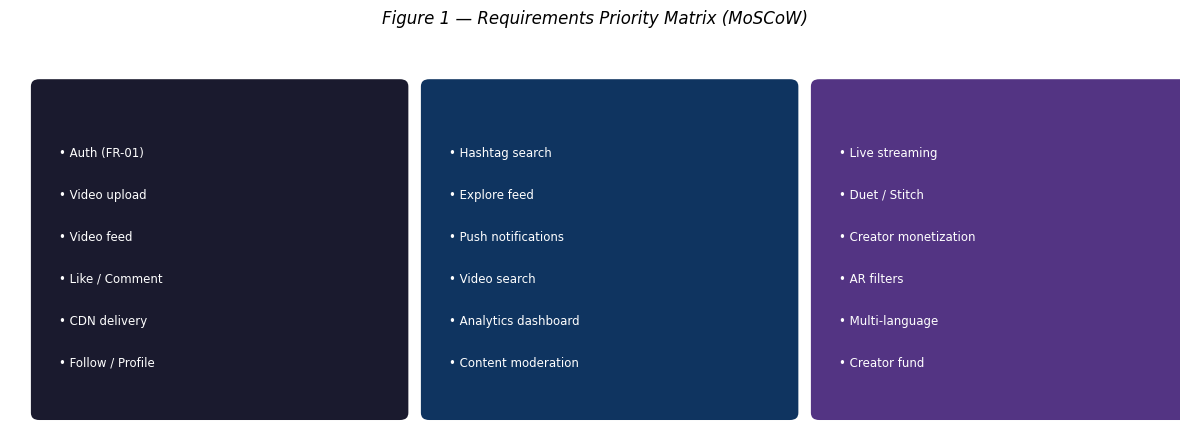

In [10]:
# ── Requirements Priority Matrix ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.set_xlim(0, 12)
ax.set_ylim(0, 4.5)
ax.axis('off')
ax.set_facecolor('#f9f9f9')

cols = [
    (0.3,  3.8, '#1a1a2e', 'white', 'MUST HAVE (MVP)'),
    (4.3,  3.8, '#0f3460', 'white', 'SHOULD HAVE (Phase 2)'),
    (8.3,  3.8, '#533483', 'white', 'NICE TO HAVE (Future)'),
]
must   = ["Auth (FR-01)", "Video upload", "Video feed", "Like / Comment", "CDN delivery", "Follow / Profile"]
should = ["Hashtag search", "Explore feed", "Push notifications", "Video search", "Analytics dashboard", "Content moderation"]
nice   = ["Live streaming", "Duet / Stitch", "Creator monetization", "AR filters", "Multi-language", "Creator fund"]

for x, y, color, fc, title in cols:
    ax.add_patch(mpatches.FancyBboxPatch((x, 0.2), 3.7, y, boxstyle="round,pad=0.1",
                                         facecolor=color, edgecolor='white', linewidth=2))
    ax.text(x + 1.85, y + 0.05, title, ha='center', va='bottom', fontsize=9,
            fontweight='bold', color=color, clip_on=False)

for i, item in enumerate(must):
    ax.text(0.5, 3.3 - i * 0.49, f"• {item}", fontsize=8.5, color='white', va='top')
for i, item in enumerate(should):
    ax.text(4.5, 3.3 - i * 0.49, f"• {item}", fontsize=8.5, color='white', va='top')
for i, item in enumerate(nice):
    ax.text(8.5, 3.3 - i * 0.49, f"• {item}", fontsize=8.5, color='white', va='top')

ax.set_title('Figure 1 — Requirements Priority Matrix (MoSCoW)', fontsize=12, pad=14, fontstyle='italic')
plt.tight_layout()
plt.show()

---
## Q2. High-Level System Architecture

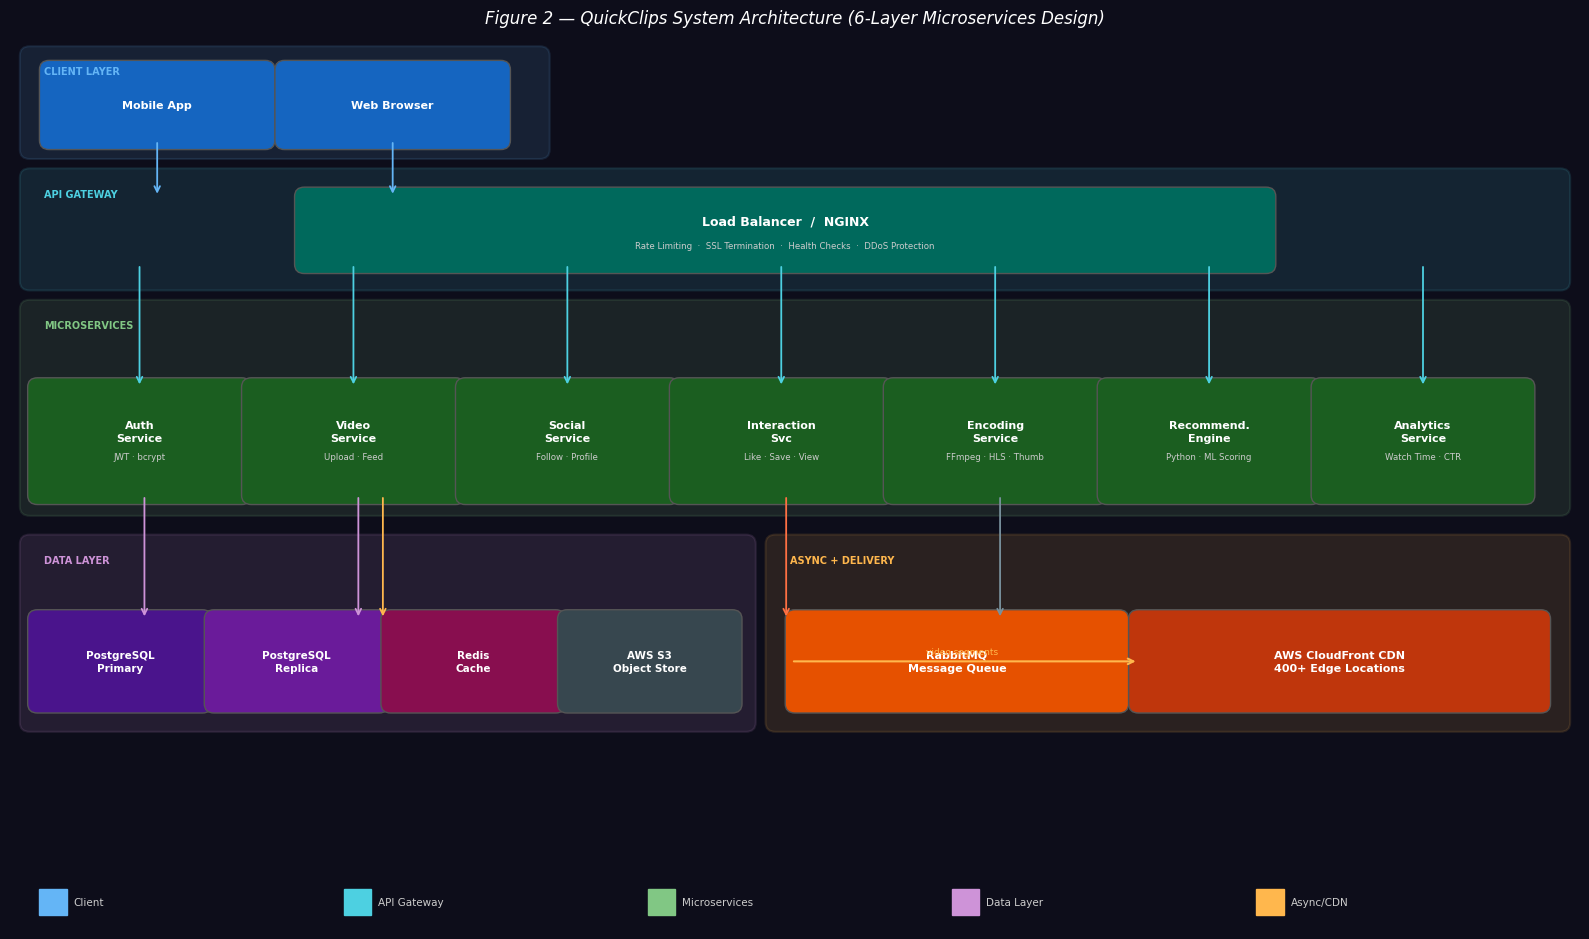

In [11]:
# ── Q2: System Architecture Diagram (Clean 6-Layer Layout) ──────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(16, 9.5))
ax.set_xlim(0, 16)
ax.set_ylim(0, 9.5)
ax.axis('off')
ax.set_facecolor('#0d0d1a')
fig.patch.set_facecolor('#0d0d1a')

def box(ax, x, y, w, h, title, sub='', bg='#1b5e20', tc='white', fs=8.0):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle='round,pad=0.1',
                 facecolor=bg, edgecolor='#555', linewidth=1))
    ax.text(x+w/2, y+h/2+(0.1 if sub else 0), title,
            ha='center', va='center', fontsize=fs, color=tc,
            fontweight='bold', linespacing=1.35)
    if sub:
        ax.text(x+w/2, y+h/2-0.16, sub,
                ha='center', va='center', fontsize=6.2, color='#ccc')

def layer(ax, x, y, w, h, label, col):
    ax.add_patch(mpatches.FancyBboxPatch((x,y), w, h, boxstyle='round,pad=0.1',
                 facecolor=col, edgecolor=col, linewidth=1.5, alpha=0.12))
    ax.text(x+0.15, y+h-0.2, label, fontsize=7, color=col, fontweight='bold')

def arr_down(ax, x, y_top, y_bot, col='#666'):
    ax.annotate('', xy=(x, y_bot), xytext=(x, y_top),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.3))

# ── Layer shading ─────────────────────────────────────────────────────────────
layer(ax, 0.2, 8.3,  5.2, 1.0,  'CLIENT LAYER',      '#64b5f6')
layer(ax, 0.2, 6.9, 15.6, 1.1,  'API GATEWAY',       '#4dd0e1')
layer(ax, 0.2, 4.5, 15.6, 2.1,  'MICROSERVICES',     '#81c784')
layer(ax, 0.2, 2.2,  7.3, 1.9,  'DATA LAYER',        '#ce93d8')
layer(ax, 7.8, 2.2,  8.0, 1.9,  'ASYNC + DELIVERY',  '#ffb74d')

# ── Row 1: Clients ────────────────────────────────────────────────────────────
box(ax, 0.4, 8.4, 2.2, 0.75, 'Mobile App',  bg='#1565c0')
box(ax, 2.8, 8.4, 2.2, 0.75, 'Web Browser', bg='#1565c0')

# ── Row 2: Gateway ────────────────────────────────────────────────────────────
box(ax, 3.0, 7.08, 9.8, 0.72, 'Load Balancer  /  NGINX',
    'Rate Limiting  ·  SSL Termination  ·  Health Checks  ·  DDoS Protection',
    bg='#00695c', fs=9)

# ── Row 3: 7 Microservices ────────────────────────────────────────────────────
SW = 2.18
services = [
    ('Auth\nService',      'JWT · bcrypt'),
    ('Video\nService',     'Upload · Feed'),
    ('Social\nService',    'Follow · Profile'),
    ('Interaction\nSvc',   'Like · Save · View'),
    ('Encoding\nService',  'FFmpeg · HLS · Thumb'),
    ('Recommend.\nEngine', 'Python · ML Scoring'),
    ('Analytics\nService', 'Watch Time · CTR'),
]
svc_xs = [0.28 + i * SW for i in range(7)]
for sx, (lbl, sub) in zip(svc_xs, services):
    box(ax, sx, 4.62, SW-0.1, 1.15, lbl, sub, bg='#1b5e20')

# ── Row 4a: Data Layer ────────────────────────────────────────────────────────
dbs = [
    ('PostgreSQL\nPrimary', '#4a148c'),
    ('PostgreSQL\nReplica',  '#6a1b9a'),
    ('Redis\nCache',         '#880e4f'),
    ('AWS S3\nObject Store', '#37474f'),
]
for i, (lbl, col) in enumerate(dbs):
    box(ax, 0.28+i*1.8, 2.4, 1.68, 0.9, lbl, bg=col, fs=7.5)

# ── Row 4b: Async + CDN ───────────────────────────────────────────────────────
box(ax, 8.0,  2.4, 3.3, 0.9, 'RabbitMQ\nMessage Queue',       bg='#e65100', fs=8)
box(ax, 11.5, 2.4, 4.1, 0.9, 'AWS CloudFront CDN\n400+ Edge Locations', bg='#bf360c', fs=8)

# ── Arrows: Clients → Gateway ─────────────────────────────────────────────────
arr_down(ax, 1.5,  8.4,  7.8, '#64b5f6')
arr_down(ax, 3.9,  8.4,  7.8, '#64b5f6')

# ── Arrows: Gateway → each Microservice ──────────────────────────────────────
for sx in svc_xs:
    arr_down(ax, sx + (SW-0.1)/2, 7.08, 5.77, '#4dd0e1')

# ── Arrows: Services → Data/Async ────────────────────────────────────────────
# Auth → PostgreSQL Primary
arr_down(ax, svc_xs[0]+(SW/2), 4.62, 3.3, '#ce93d8')
# Video → PostgreSQL Replica
arr_down(ax, svc_xs[1]+(SW/2), 4.62, 3.3, '#ce93d8')
# Interaction → Redis
arr_down(ax, svc_xs[3]+(SW/2), 4.62, 3.3, '#ff7043')
# Encoding → S3
arr_down(ax, svc_xs[4]+(SW/2), 4.62, 3.3, '#78909c')
# Video → RabbitMQ
arr_down(ax, svc_xs[1]+(SW/2)+0.25, 4.62, 3.3, '#ffb74d')
# S3 → CloudFront (horizontal)
ax.annotate('', xy=(11.5, 2.85), xytext=(7.96, 2.85),
            arrowprops=dict(arrowstyle='->', color='#ffb74d', lw=1.5))
ax.text(9.7, 2.93, 'video segments', ha='center', fontsize=6.5, color='#ffb74d')

# ── Legend ────────────────────────────────────────────────────────────────────
for i, (col, lbl) in enumerate([
    ('#64b5f6','Client'), ('#4dd0e1','API Gateway'),
    ('#81c784','Microservices'), ('#ce93d8','Data Layer'), ('#ffb74d','Async/CDN')
]):
    ax.add_patch(mpatches.Rectangle((0.3+i*3.1, 0.15), 0.28, 0.28, color=col, zorder=5))
    ax.text(0.65+i*3.1, 0.29, lbl, color='#ccc', fontsize=7.5, va='center')

ax.set_title('Figure 2 — QuickClips System Architecture (6-Layer Microservices Design)',
             fontsize=12, color='white', pad=10, fontstyle='italic')
plt.tight_layout()
plt.show()

In [12]:
# ── Q2: Component Description Table ─────────────────────────────────────────
from IPython.display import display, HTML

components = [
    ("Load Balancer",         "NGINX / AWS ALB",        "Distribute traffic across API servers. Health checks. SSL termination. Rate limiting"),
    ("Auth Service",          "Node.js",                "Register, login, JWT issuance and validation. bcrypt password hashing"),
    ("Video Service",         "Node.js",                "Upload handling, metadata storage, feed generation with cursor pagination"),
    ("Social Service",        "Node.js",                "Follow/unfollow, profile pages, follower graph management"),
    ("Interaction Service",   "Node.js",                "Like, comment, save — writes to Redis counters + PostgreSQL"),
    ("Encoding Service",      "FFmpeg + Node.js",       "Transcode uploaded videos to multiple resolutions. Generate HLS segments. Extract thumbnails"),
    ("Recommendation Engine", "Python",                 "Hybrid scoring: content-based + collaborative + trending. Updates feed cache"),
    ("Analytics Service",     "Node.js",                "Track watch time, click-through rate, completion rate. Feeds back to recommendation"),
    ("PostgreSQL",            "Primary + Replica",      "Source of truth for all structured data. Read replicas absorb 80% of queries"),
    ("Redis",                 "ioredis",                "Feed caching (TTL=5min), like/view counters (INCR), rate limiting"),
    ("AWS S3",                "Object storage",         "Video files, HLS segments, thumbnails, avatars. 11-nines durability"),
    ("CloudFront",            "CDN",                    "Global video delivery. Edge caching of HLS segments for low-latency playback"),
    ("Message Queue",         "RabbitMQ / SQS",         "Decouples upload from encoding. Enables retry on encoding failure"),
]

tbl = "<h3>2.1 Component Descriptions</h3><table class='req'><thead><tr><th>Component</th><th>Technology</th><th>Responsibility</th></tr></thead><tbody>"
for comp, tech, resp in components:
    tbl += f"<tr><td class='rid'>{comp}</td><td>{tech}</td><td>{resp}</td></tr>\n"
tbl += "</tbody></table>"
display(HTML(tbl))

Component,Technology,Responsibility
Load Balancer,NGINX / AWS ALB,Distribute traffic across API servers. Health checks. SSL termination. Rate limiting
Auth Service,Node.js,"Register, login, JWT issuance and validation. bcrypt password hashing"
Video Service,Node.js,"Upload handling, metadata storage, feed generation with cursor pagination"
Social Service,Node.js,"Follow/unfollow, profile pages, follower graph management"
Interaction Service,Node.js,"Like, comment, save — writes to Redis counters + PostgreSQL"
Encoding Service,FFmpeg + Node.js,Transcode uploaded videos to multiple resolutions. Generate HLS segments. Extract thumbnails
Recommendation Engine,Python,Hybrid scoring: content-based + collaborative + trending. Updates feed cache
Analytics Service,Node.js,"Track watch time, click-through rate, completion rate. Feeds back to recommendation"
PostgreSQL,Primary + Replica,Source of truth for all structured data. Read replicas absorb 80% of queries
Redis,ioredis,"Feed caching (TTL=5min), like/view counters (INCR), rate limiting"


In [13]:
# ── Q2: Request Lifecycle Flow ───────────────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════════╗
║              REQUEST LIFECYCLE — FEED REQUEST                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Client → Load Balancer → Video Service                          ║
║      → Redis GET feed:{user_id}                                  ║
║          ├── HIT  → return cached result (< 1ms)                 ║
║          └── MISS → PostgreSQL query (cursor paginated JOIN)     ║
║                   → Recommendation Engine ranking               ║
║                   → Redis SET feed:{user_id} TTL=300s           ║
║                   → return to client                             ║
╠══════════════════════════════════════════════════════════════════╣
║              REQUEST LIFECYCLE — VIDEO UPLOAD                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Client → Load Balancer → Video Service                          ║
║      → Validate JWT (auth middleware)                            ║
║      → Validate request (Joi schema)                             ║
║      → INSERT video record (status='processing')                 ║
║      → Upload to S3 (presigned URL or multipart)                 ║
║      → Publish event to Message Queue                            ║
║      ← 201 Created { video_id, status: "processing" }           ║
║                                                                  ║
║  Message Queue → Encoding Worker                                 ║
║      → FFmpeg: 360p + 720p + 1080p + HLS segments               ║
║      → Upload encoded files to S3                                ║
║      → UPDATE videos SET status='ready'                         ║
║      → Invalidate feed cache for all followers                   ║
╚══════════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════════╗
║              REQUEST LIFECYCLE — FEED REQUEST                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                                                  ║
║  Client → Load Balancer → Video Service                          ║
║      → Redis GET feed:{user_id}                                  ║
║          ├── HIT  → return cached result (< 1ms)                 ║
║          └── MISS → PostgreSQL query (cursor paginated JOIN)     ║
║                   → Recommendation Engine ranking               ║
║                   → Redis SET feed:{user_id} TTL=300s           ║
║                   → return to client                             ║
╠══════════════════════════════════════════════════════════════════╣
║              REQUEST LIFECYCLE — VIDEO UPLOAD                   ║
╠══════════════════════════════════════════════════════════════════╣
║                                    

---
## Q3. Video Processing & Recommendation Engine

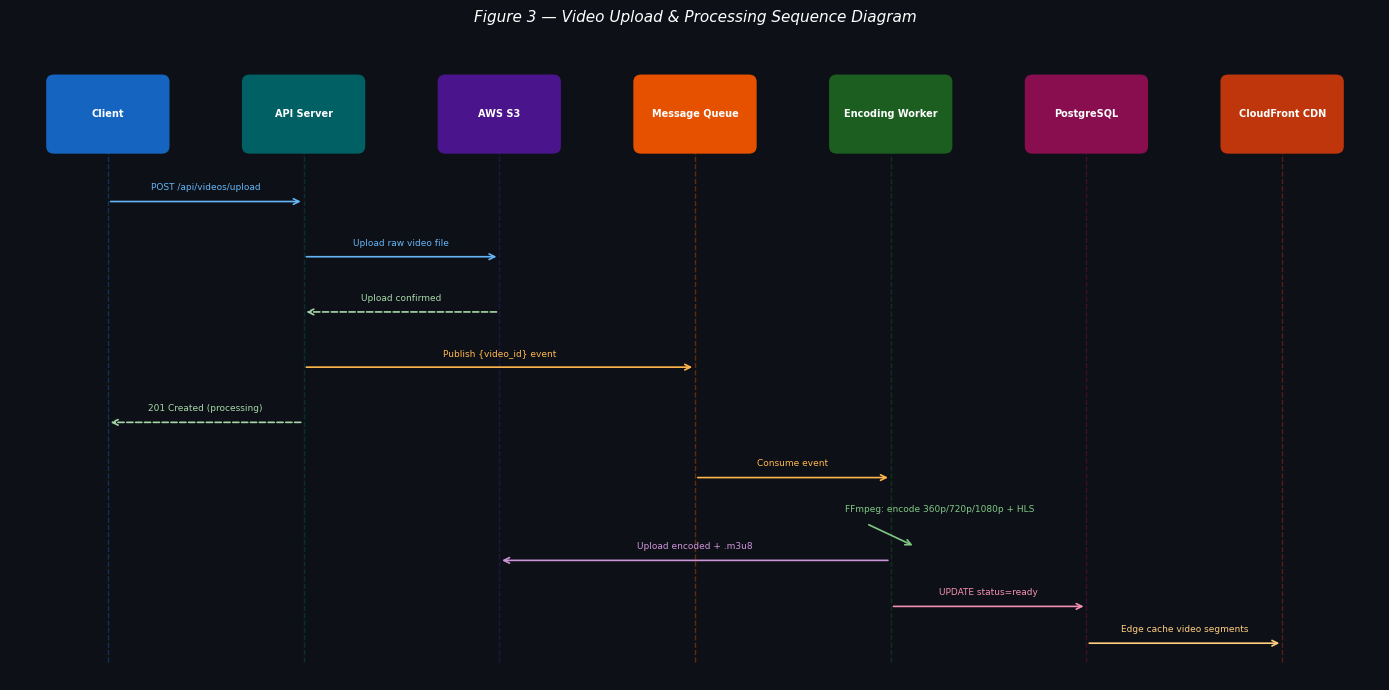

In [14]:
# ── Q3: Video Upload & Processing Flow ──────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14)
ax.set_ylim(0, 7)
ax.axis('off')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

actors = [
    (1,    'Client'),
    (3,    'API Server'),
    (5,    'AWS S3'),
    (7,    'Message Queue'),
    (9,    'Encoding Worker'),
    (11,   'PostgreSQL'),
    (13,   'CloudFront CDN'),
]
colors = ['#1565c0','#006064','#4a148c','#e65100','#1b5e20','#880e4f','#bf360c']

for (x, name), col in zip(actors, colors):
    ax.add_patch(mpatches.FancyBboxPatch((x-0.55, 5.8), 1.1, 0.7,
                                         boxstyle="round,pad=0.08", facecolor=col, edgecolor='none'))
    ax.text(x, 6.15, name, ha='center', va='center', fontsize=7, color='white', fontweight='bold')
    ax.plot([x, x], [0.2, 5.8], color=col, linewidth=1, linestyle='--', alpha=0.4)

msgs = [
    (1, 3, 5.2, 'POST /api/videos/upload', '#64b5f6'),
    (3, 5, 4.6, 'Upload raw video file',    '#64b5f6'),
    (5, 3, 4.0, 'Upload confirmed',         '#a5d6a7', True),
    (3, 7, 3.4, 'Publish {video_id} event', '#ffb74d'),
    (3, 1, 2.8, '201 Created (processing)', '#a5d6a7', True),
    (7, 9, 2.2, 'Consume event',            '#ffb74d'),
    (9, 9, 1.7, 'FFmpeg: encode 360p/720p/1080p + HLS', '#81c784'),
    (9, 5, 1.3, 'Upload encoded + .m3u8',   '#ce93d8'),
    (9,11, 0.8, 'UPDATE status=ready',      '#f48fb1'),
    (11,13,0.4, 'Edge cache video segments', '#ffcc80'),
]

for msg in msgs:
    if len(msg) == 6:
        x1, x2, y, label, col, dashed = msg
    else:
        x1, x2, y, label, col = msg
        dashed = False
    if x1 == x2:
        ax.annotate('', xy=(x1 + 0.25, y - 0.25), xytext=(x1 - 0.25, y),
                    arrowprops=dict(arrowstyle='->', color=col, lw=1.2))
    else:
        style = dict(arrowstyle='->', color=col, lw=1.2, linestyle='dashed' if dashed else 'solid')
        ax.annotate('', xy=(x2, y), xytext=(x1, y),
                    arrowprops=style)
    mx = (x1 + x2) / 2 if x1 != x2 else x1 + 0.5
    ax.text(mx, y + 0.1, label, ha='center', va='bottom', fontsize=6.5, color=col)

phase_boxes = [
    (0.2, 4.2, 6.1, 'Phase 1: Upload', '#1565c0'),
    (0.2, 2.6, 5.5, 'Phase 2: Async Encoding', '#1b5e20'),
]
ax.set_title('Figure 3 — Video Upload & Processing Sequence Diagram',
             fontsize=11, color='white', pad=10, fontstyle='italic')
plt.tight_layout()
plt.show()

In [15]:
# ── Q3: HLS Adaptive Bitrate Streaming ──────────────────────────────────────
print("""
╔══════════════════════════════════════════════════════════════╗
║        HLS ADAPTIVE BITRATE STREAMING — HOW IT WORKS        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  User presses Play                                           ║
║      │                                                       ║
║      ▼                                                       ║
║  Request .m3u8 manifest from CloudFront                      ║
║      │                                                       ║
║      ▼                                                       ║
║  Manifest lists available quality levels:                    ║
║    #EXT-X-STREAM-INF:BANDWIDTH=800000   → 360p              ║
║    #EXT-X-STREAM-INF:BANDWIDTH=2500000  → 720p              ║
║    #EXT-X-STREAM-INF:BANDWIDTH=8000000  → 1080p             ║
║      │                                                       ║
║      ▼                                                       ║
║  Client measures available bandwidth                         ║
║  ┌───────────────────────────────────────┐                  ║
║  │ Bandwidth < 1 Mbps  → Request 360p   │                  ║
║  │ Bandwidth 1–5 Mbps  → Request 720p   │                  ║
║  │ Bandwidth > 5 Mbps  → Request 1080p  │                  ║
║  └───────────────────────────────────────┘                  ║
║      │                                                       ║
║      ▼                                                       ║
║  Bandwidth drops mid-video → switch quality seamlessly       ║
║  No buffering spinner — just quality adaptation              ║
║                                                              ║
║  This is why TikTok, YouTube, and Netflix never buffer.      ║
╚══════════════════════════════════════════════════════════════╝
""")


╔══════════════════════════════════════════════════════════════╗
║        HLS ADAPTIVE BITRATE STREAMING — HOW IT WORKS        ║
╠══════════════════════════════════════════════════════════════╣
║                                                              ║
║  User presses Play                                           ║
║      │                                                       ║
║      ▼                                                       ║
║  Request .m3u8 manifest from CloudFront                      ║
║      │                                                       ║
║      ▼                                                       ║
║  Manifest lists available quality levels:                    ║
║    #EXT-X-STREAM-INF:BANDWIDTH=800000   → 360p              ║
║    #EXT-X-STREAM-INF:BANDWIDTH=2500000  → 720p              ║
║    #EXT-X-STREAM-INF:BANDWIDTH=8000000  → 1080p             ║
║      │                                                       ║
║      ▼                    

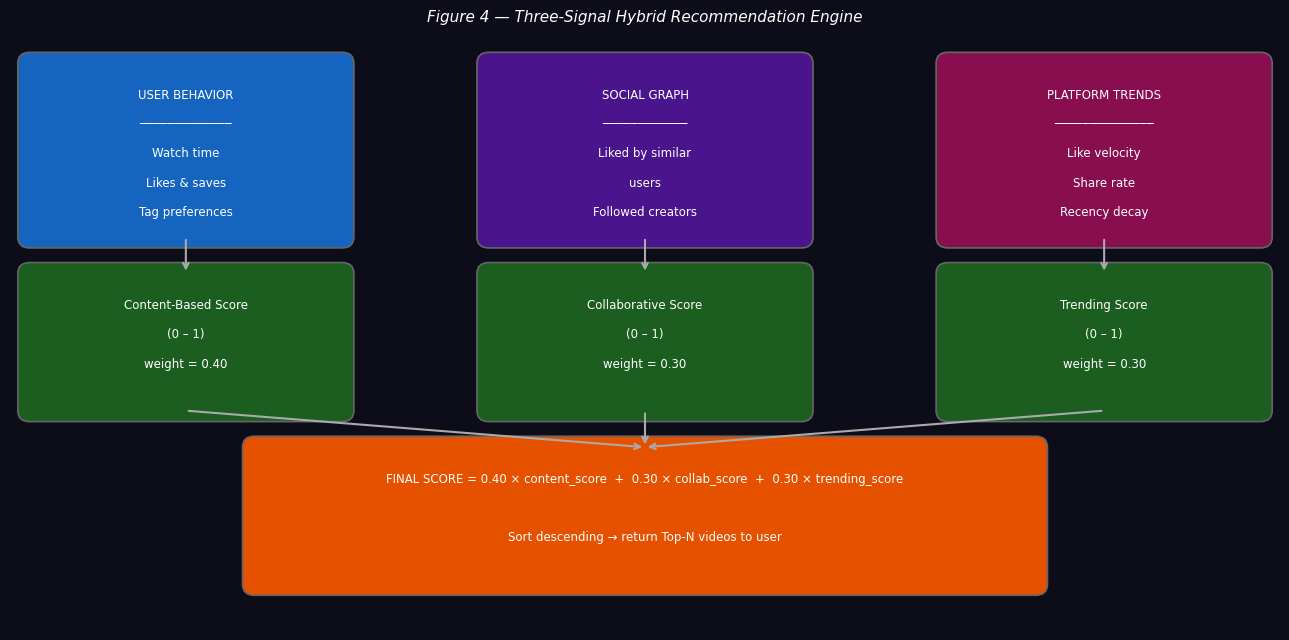


Trending Score Formula:
  trending_score = log(1 + likes + 0.5×comments + 2×shares) × e^(-0.05 × age_hours)

  log(1 + engagement) → compresses viral outliers (1M likes ≠ 1000× better than 1K)
  e^(-decay × age)    → exponential decay: 2-day-old video loses ~90% trending boost
  shares × 2          → shares signal virality more strongly than passive likes



In [16]:
# ── Q3: Recommendation Engine Architecture ───────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(13, 6.5))
ax.set_xlim(0, 13)
ax.set_ylim(0, 6.5)
ax.axis('off')
ax.set_facecolor('#0d0d1a')
fig.patch.set_facecolor('#0d0d1a')

def rbox(ax, x, y, w, h, lines, color, tc='white', fs=8.5):
    ax.add_patch(mpatches.FancyBboxPatch((x, y), w, h, boxstyle="round,pad=0.12",
                                         facecolor=color, edgecolor='#666', linewidth=1.2))
    for i, line in enumerate(lines):
        ax.text(x + w/2, y + h - 0.28 - i*0.32, line,
                ha='center', va='top', fontsize=fs, color=tc)

def arr(ax, x1, y1, x2, y2, color='#aaa'):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

# ── Input signals ─────────────────────────────────────────────────────────────
rbox(ax, 0.2, 4.3, 3.2, 1.9, ['USER BEHAVIOR', '─────────────', 'Watch time',
                                'Likes & saves', 'Tag preferences'], '#1565c0')
rbox(ax, 4.9, 4.3, 3.2, 1.9, ['SOCIAL GRAPH', '────────────', 'Liked by similar',
                                'users', 'Followed creators'], '#4a148c')
rbox(ax, 9.6, 4.3, 3.2, 1.9, ['PLATFORM TRENDS', '──────────────', 'Like velocity',
                                'Share rate', 'Recency decay'], '#880e4f')

# ── Score components ──────────────────────────────────────────────────────────
rbox(ax, 0.2, 2.4, 3.2, 1.5, ['Content-Based Score', '(0 – 1)', 'weight = 0.40'], '#1b5e20')
rbox(ax, 4.9, 2.4, 3.2, 1.5, ['Collaborative Score', '(0 – 1)', 'weight = 0.30'], '#1b5e20')
rbox(ax, 9.6, 2.4, 3.2, 1.5, ['Trending Score', '(0 – 1)', 'weight = 0.30'], '#1b5e20')

# ── Final score ───────────────────────────────────────────────────────────────
rbox(ax, 2.5, 0.5, 8.0, 1.5,
     ['FINAL SCORE = 0.40 × content_score  +  0.30 × collab_score  +  0.30 × trending_score',
      '', 'Sort descending → return Top-N videos to user'],
     '#e65100', tc='white', fs=8.5)

# ── Arrows ────────────────────────────────────────────────────────────────────
for x_in in [1.8, 6.5, 11.2]:
    arr(ax, x_in, 4.3, x_in, 3.9, '#aaa')
for x_sc in [1.8, 6.5, 11.2]:
    arr(ax, x_sc, 2.4, 6.5, 2.0, '#aaa')

ax.set_title('Figure 4 — Three-Signal Hybrid Recommendation Engine',
             fontsize=11, color='white', pad=10, fontstyle='italic')
plt.tight_layout()
plt.show()

print("""
Trending Score Formula:
  trending_score = log(1 + likes + 0.5×comments + 2×shares) × e^(-0.05 × age_hours)

  log(1 + engagement) → compresses viral outliers (1M likes ≠ 1000× better than 1K)
  e^(-decay × age)    → exponential decay: 2-day-old video loses ~90% trending boost
  shares × 2          → shares signal virality more strongly than passive likes
""")

---
## Q4. Database Design

In [17]:
# ── Q4: Database Architecture Decisions ─────────────────────────────────────
from IPython.display import display, HTML

db_choices = [
    ("User profiles, video metadata, relationships", "PostgreSQL",      "ACID compliance, complex JOINs, foreign key integrity"),
    ("Feed cache, counters (likes/views)",           "Redis",           "Sub-millisecond reads, atomic INCR, no DB bottleneck"),
    ("Video files, thumbnails, HLS segments",        "AWS S3",          "Binary objects, unlimited scale, CloudFront integration"),
    ("Full-text search (future scope)",              "Elasticsearch",   "Inverted index for fast title/tag/description search"),
]

tbl = "<h3>4.1 Database Architecture Decision</h3><table class='req'><thead><tr><th>Data Type</th><th>Technology</th><th>Reason</th></tr></thead><tbody>"
for dtype, tech, reason in db_choices:
    tbl += f"<tr><td>{dtype}</td><td class='rid'>{tech}</td><td>{reason}</td></tr>"
tbl += "</tbody></table>"
display(HTML(tbl))

Data Type,Technology,Reason
"User profiles, video metadata, relationships",PostgreSQL,"ACID compliance, complex JOINs, foreign key integrity"
"Feed cache, counters (likes/views)",Redis,"Sub-millisecond reads, atomic INCR, no DB bottleneck"
"Video files, thumbnails, HLS segments",AWS S3,"Binary objects, unlimited scale, CloudFront integration"
Full-text search (future scope),Elasticsearch,Inverted index for fast title/tag/description search


/tmp/ipykernel_7510/3926595621.py:99: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_7510/3926595621.py:99: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128273 (\N{KEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


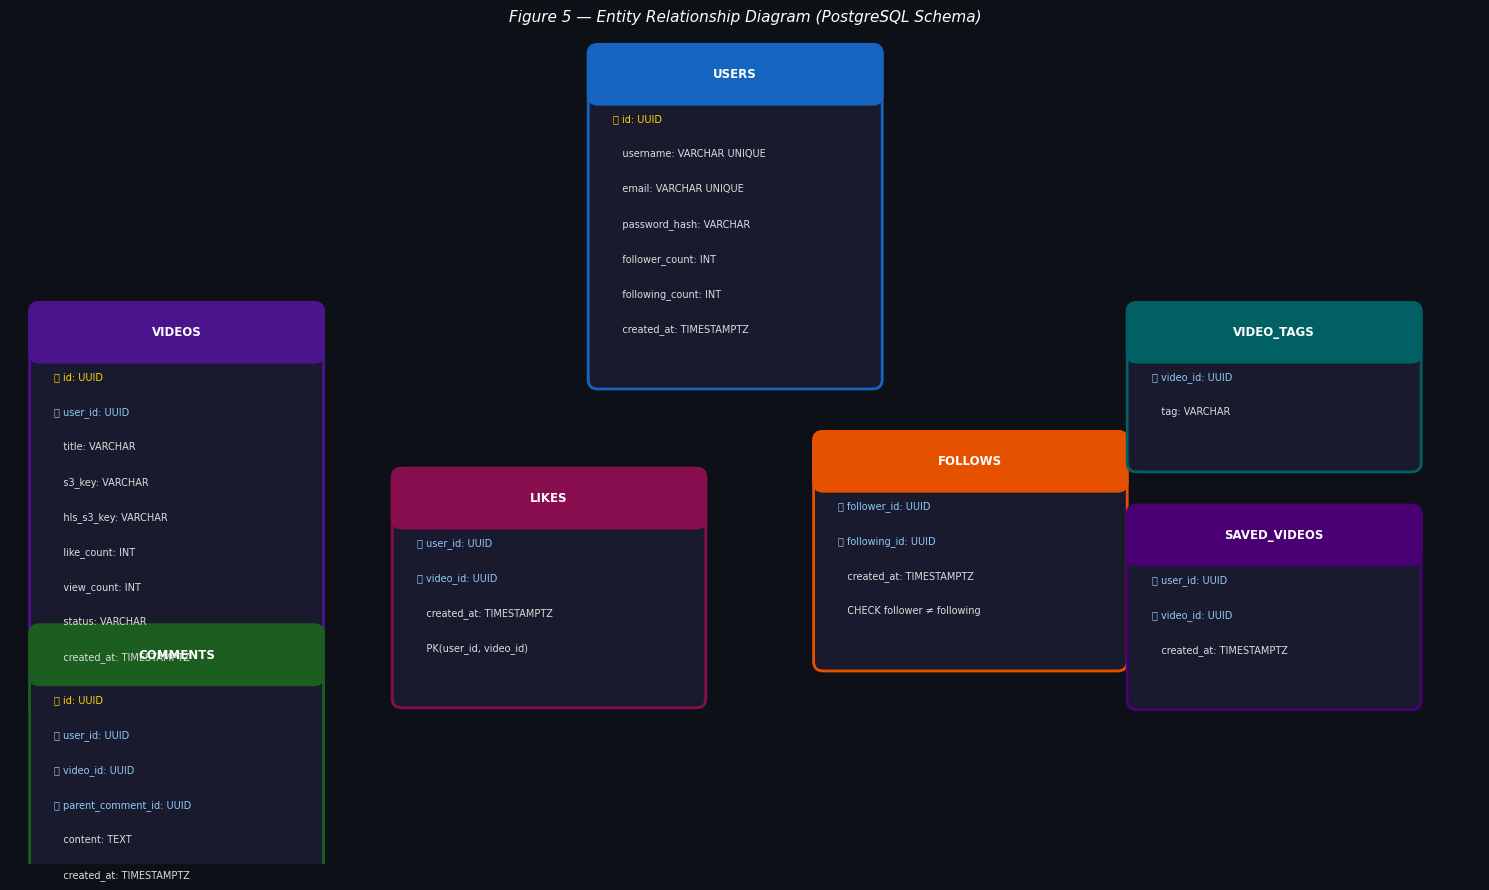

In [18]:
# ── Q4: Entity-Relationship Diagram ─────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax = plt.subplots(figsize=(15, 9))
ax.set_xlim(0, 15)
ax.set_ylim(0, 9)
ax.axis('off')
ax.set_facecolor('#0d1117')
fig.patch.set_facecolor('#0d1117')

def entity(ax, x, y, title, fields, w=2.8, color='#1a237e'):
    h = 0.38 * (len(fields) + 1) + 0.5
    ax.add_patch(mpatches.FancyBboxPatch((x, y - h), w, h, boxstyle="round,pad=0.1",
                                         facecolor='#1a1a2e', edgecolor=color, linewidth=2))
    ax.add_patch(mpatches.FancyBboxPatch((x, y - 0.45), w, 0.45, boxstyle="round,pad=0.1",
                                         facecolor=color, edgecolor=color, linewidth=2))
    ax.text(x + w/2, y - 0.22, title, ha='center', va='center',
            fontsize=8.5, fontweight='bold', color='white')
    for i, (pk, field) in enumerate(fields):
        color_f = '#FFD700' if pk == 'PK' else ('#90CAF9' if pk == 'FK' else '#ddd')
        prefix  = '🔑 ' if pk == 'PK' else ('🔗 ' if pk == 'FK' else '   ')
        ax.text(x + 0.15, y - 0.65 - i*0.38, f"{prefix}{field}",
                fontsize=7, color=color_f, va='top')
    return h

def rel(ax, x1, y1, x2, y2, label=''):
    ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                arrowprops=dict(arrowstyle='<->', color='#555', lw=1.2))
    if label:
        ax.text((x1+x2)/2, (y1+y2)/2 + 0.1, label, fontsize=6.5,
                color='#aaa', ha='center')

# USERS
entity(ax, 6.0, 8.8, 'USERS', [
    ('PK', 'id: UUID'),
    ('', 'username: VARCHAR UNIQUE'),
    ('', 'email: VARCHAR UNIQUE'),
    ('', 'password_hash: VARCHAR'),
    ('', 'follower_count: INT'),
    ('', 'following_count: INT'),
    ('', 'created_at: TIMESTAMPTZ'),
], color='#1565c0')

# VIDEOS
entity(ax, 0.3, 6.0, 'VIDEOS', [
    ('PK', 'id: UUID'),
    ('FK', 'user_id: UUID'),
    ('', 'title: VARCHAR'),
    ('', 's3_key: VARCHAR'),
    ('', 'hls_s3_key: VARCHAR'),
    ('', 'like_count: INT'),
    ('', 'view_count: INT'),
    ('', 'status: VARCHAR'),
    ('', 'created_at: TIMESTAMPTZ'),
], color='#4a148c')

# LIKES
entity(ax, 4.0, 4.2, 'LIKES', [
    ('FK', 'user_id: UUID'),
    ('FK', 'video_id: UUID'),
    ('', 'created_at: TIMESTAMPTZ'),
    ('', 'PK(user_id, video_id)'),
], w=3.0, color='#880e4f')

# COMMENTS
entity(ax, 0.3, 2.5, 'COMMENTS', [
    ('PK', 'id: UUID'),
    ('FK', 'user_id: UUID'),
    ('FK', 'video_id: UUID'),
    ('FK', 'parent_comment_id: UUID'),
    ('', 'content: TEXT'),
    ('', 'created_at: TIMESTAMPTZ'),
], color='#1b5e20')

# FOLLOWS
entity(ax, 8.3, 4.6, 'FOLLOWS', [
    ('FK', 'follower_id: UUID'),
    ('FK', 'following_id: UUID'),
    ('', 'created_at: TIMESTAMPTZ'),
    ('', 'CHECK follower ≠ following'),
], w=3.0, color='#e65100')

# VIDEO_TAGS
entity(ax, 11.5, 6.0, 'VIDEO_TAGS', [
    ('FK', 'video_id: UUID'),
    ('', 'tag: VARCHAR'),
], color='#006064')

# SAVED_VIDEOS
entity(ax, 11.5, 3.8, 'SAVED_VIDEOS', [
    ('FK', 'user_id: UUID'),
    ('FK', 'video_id: UUID'),
    ('', 'created_at: TIMESTAMPTZ'),
], color='#4a0072')

ax.set_title('Figure 5 — Entity Relationship Diagram (PostgreSQL Schema)',
             fontsize=11, color='white', pad=10, fontstyle='italic')
plt.tight_layout()
plt.show()

In [19]:
# ── Q4: Key Design Decisions & Critical SQL Queries ──────────────────────────
print("""═══════════════════════════════════════════════════════════════════
KEY DATABASE DESIGN DECISIONS
═══════════════════════════════════════════════════════════════════

1. UUID PRIMARY KEYS
   id UUID PRIMARY KEY DEFAULT gen_random_uuid()
   → No sequential IDs in URLs (cannot enumerate video/1, video/2...)
   → Works across distributed database shards
   → No integer overflow at scale

2. COMPOSITE PRIMARY KEY (no duplicate likes)
   PRIMARY KEY (user_id, video_id)  -- likes table
   → DB itself enforces "one like per user per video"
   → No application-level check needed, no race condition

3. PARTIAL FEED INDEX
   CREATE INDEX idx_videos_feed
       ON videos (created_at DESC)
       WHERE status = 'ready' AND deleted_at IS NULL;
   → Covers ONLY rows the feed query needs
   → At 100M videos: 5M wasted entries avoided vs full index

4. DENORMALIZED COUNTERS (for O(1) reads)
   Without: SELECT COUNT(*) FROM follows WHERE following_id = $1
            → full table scan at 10M followers → 500ms+
   With:    SELECT follower_count FROM users WHERE id = $1
            → O(1) index read → < 1ms

5. SOFT DELETES
   deleted_at TIMESTAMPTZ  -- NULL = active, non-null = deleted
   → GDPR: data "deleted" without destroying referential integrity
   → Analytics: deleted user data still in historical metrics

═══════════════════════════════════════════════════════════════════
FEED QUERY — Cursor Pagination
═══════════════════════════════════════════════════════════════════""")

feed_sql = """
SELECT
    v.id, v.title, v.description,
    v.like_count, v.comment_count, v.view_count,
    v.created_at,
    u.id AS author_id, u.username AS author_username,
    EXISTS (
        SELECT 1 FROM likes
        WHERE user_id = $1 AND video_id = v.id
    ) AS is_liked,
    EXISTS (
        SELECT 1 FROM saved_videos
        WHERE user_id = $1 AND video_id = v.id
    ) AS is_saved
FROM  videos v
JOIN  users u ON u.id = v.user_id
WHERE v.status     = 'ready'
AND   v.deleted_at IS NULL
AND   ($2::timestamptz IS NULL OR v.created_at < $2::timestamptz)
ORDER BY v.created_at DESC
LIMIT $3;

-- Parameters: $1=userId, $2=cursor_timestamp, $3=limit+1
-- EXISTS() stops at first match — orders of magnitude faster than COUNT()
"""
print(feed_sql)

═══════════════════════════════════════════════════════════════════
KEY DATABASE DESIGN DECISIONS
═══════════════════════════════════════════════════════════════════

1. UUID PRIMARY KEYS
   id UUID PRIMARY KEY DEFAULT gen_random_uuid()
   → No sequential IDs in URLs (cannot enumerate video/1, video/2...)
   → Works across distributed database shards
   → No integer overflow at scale

2. COMPOSITE PRIMARY KEY (no duplicate likes)
   PRIMARY KEY (user_id, video_id)  -- likes table
   → DB itself enforces "one like per user per video"
   → No application-level check needed, no race condition

3. PARTIAL FEED INDEX
   CREATE INDEX idx_videos_feed
       ON videos (created_at DESC)
       WHERE status = 'ready' AND deleted_at IS NULL;
   → Covers ONLY rows the feed query needs
   → At 100M videos: 5M wasted entries avoided vs full index

4. DENORMALIZED COUNTERS (for O(1) reads)
   Without: SELECT COUNT(*) FROM follows WHERE following_id = $1
            → full table scan at 10M followers 

---
## Q5. Python Implementation — OOP Simulation

Two simulation engines are included:
1. **`RecommendationEngine`** — Basic OOP hybrid scoring (content + collaborative + trending)
2. **`QuickClipsPlatform`** — TikTok-style production architecture (MySQL + Cassandra + Redis + Kafka + two-stage ML pipeline)


In [20]:
# ── Q5.1: Recommendation Engine (OOP — Content + Collaborative + Trending) ───
# Complete self-contained implementation

import math
import heapq
from datetime import datetime, timedelta, timezone
from collections import defaultdict


class Video:
    """
    Represents a short video on the QuickClips platform.

    Interaction weights used by the recommendation engine:
      Save    → weight 5.0   (user wants to revisit = strongest signal)
      Like    → weight 2.0   (explicit approval)
      Comment → weight 1.5   (engagement: user took action)
      Watch   → weight 0.01 × seconds (passive but valuable at scale)
    """
    def __init__(self, video_id, title, tags, creator_id,
                 like_count=0, comment_count=0, share_count=0,
                 view_count=0, watch_time_total=0.0, created_at=None):
        self.video_id         = video_id
        self.title            = title
        self.tags             = [t.lower().strip() for t in tags]
        self.creator_id       = creator_id
        self.like_count       = like_count
        self.comment_count    = comment_count
        self.share_count      = share_count
        self.view_count       = view_count
        self.watch_time_total = watch_time_total
        self.created_at       = created_at or datetime.now(timezone.utc)

    def engagement_rate(self):
        if self.view_count == 0:
            return 0.0
        return (self.like_count + self.comment_count + self.share_count) / self.view_count

    def __repr__(self):
        return f"Video(id={self.video_id!r}, title={self.title!r})"


class User:
    SAVE_WEIGHT    = 5.0
    LIKE_WEIGHT    = 2.0
    COMMENT_WEIGHT = 1.5
    WATCH_WEIGHT   = 0.01  # per second

    def __init__(self, user_id, username):
        self.user_id          = user_id
        self.username         = username
        self.watch_history    = {}
        self.liked_videos     = set()
        self.saved_videos     = set()
        self.commented_videos = set()
        self.tag_preferences  = defaultdict(float)

    def watch_video(self, video_id, seconds, tags):
        self.watch_history[video_id] = self.watch_history.get(video_id, 0) + seconds
        for tag in tags:
            self.tag_preferences[tag] += seconds * self.WATCH_WEIGHT

    def like_video(self, video_id, tags):
        self.liked_videos.add(video_id)
        for tag in tags: self.tag_preferences[tag] += self.LIKE_WEIGHT

    def save_video(self, video_id, tags):
        self.saved_videos.add(video_id)
        for tag in tags: self.tag_preferences[tag] += self.SAVE_WEIGHT

    def comment_on_video(self, video_id, tags):
        self.commented_videos.add(video_id)
        for tag in tags: self.tag_preferences[tag] += self.COMMENT_WEIGHT

    def get_seen_videos(self):
        return set(self.watch_history) | self.liked_videos | self.saved_videos | self.commented_videos

    def get_top_tags(self, n=5):
        return sorted(self.tag_preferences.items(), key=lambda x: -x[1])[:n]


class RecommendationEngine:
    """
    Hybrid recommendation engine.

    Final Score Formula:
        score = 0.40 × content_score
              + 0.30 × collaborative_score
              + 0.30 × trending_score

    Trending Score:
        trending = log(1 + engagement) × e^(-0.05 × age_hours)
    """
    WEIGHT_CONTENT       = 0.40
    WEIGHT_COLLABORATIVE = 0.30
    WEIGHT_TRENDING      = 0.30
    TRENDING_DECAY_RATE  = 0.05
    TOP_SIMILAR_USERS    = 3

    def __init__(self):
        self.users  = {}
        self.videos = {}

    def add_user(self, user):  self.users[user.user_id]   = user
    def add_video(self, video): self.videos[video.video_id] = video

    def _trending_score(self, video):
        age_h = (datetime.now(timezone.utc) - video.created_at).total_seconds() / 3600
        eng   = video.like_count + 0.5*video.comment_count + 2.0*video.share_count
        return math.log(1 + eng) * math.exp(-self.TRENDING_DECAY_RATE * age_h)

    def _all_trending(self):
        raw = {vid: self._trending_score(v) for vid, v in self.videos.items()}
        mx  = max(raw.values()) if raw else 1.0
        return {vid: s/mx for vid, s in raw.items()}

    def _content_score(self, user, video):
        if not user.tag_preferences or not video.tags: return 0.0
        mx = max(user.tag_preferences.values()) or 1
        return sum(user.tag_preferences.get(t, 0)/mx for t in video.tags) / len(video.tags)

    def _cosine_sim(self, ua, ub):
        common = set(ua.tag_preferences) & set(ub.tag_preferences)
        if not common: return 0.0
        dot = sum(ua.tag_preferences[t]*ub.tag_preferences[t] for t in common)
        ma  = math.sqrt(sum(v**2 for v in ua.tag_preferences.values()))
        mb  = math.sqrt(sum(v**2 for v in ub.tag_preferences.values()))
        return dot/(ma*mb) if ma and mb else 0.0

    def _collab_score(self, target, video):
        sims = [(self._cosine_sim(target, u), u)
                for uid, u in self.users.items() if uid != target.user_id
                if self._cosine_sim(target, u) > 0]
        if not sims: return 0.0
        score = 0.0
        for sim, u in heapq.nlargest(self.TOP_SIMILAR_USERS, sims, key=lambda x: x[0]):
            vid = video.video_id
            if vid in u.saved_videos:       score += sim * 3.0
            elif vid in u.liked_videos:     score += sim * 2.0
            elif vid in u.watch_history:    score += sim * (u.watch_history[vid]/60.0)
        return min(score, 1.0)

    def generate_feed(self, user_id, feed_size=10):
        user    = self.users[user_id]
        seen    = user.get_seen_videos()
        t_map   = self._all_trending()
        results = []
        for vid_id, video in self.videos.items():
            if vid_id in seen: continue
            c  = self._content_score(user, video)
            cf = self._collab_score(user, video)
            t  = t_map.get(vid_id, 0.0)
            final = self.WEIGHT_CONTENT*c + self.WEIGHT_COLLABORATIVE*cf + self.WEIGHT_TRENDING*t
            results.append({'video': video, 'final_score': round(final, 4),
                            'content_score': round(c, 4), 'collab_score': round(cf, 4),
                            'trending_score': round(t, 4)})
        return sorted(results, key=lambda x: -x['final_score'])[:feed_size]

print("✓ Classes defined: Video, User, RecommendationEngine")
print("  → Hybrid formula: 0.40×content + 0.30×collaborative + 0.30×trending")

✓ Classes defined: Video, User, RecommendationEngine
  → Hybrid formula: 0.40×content + 0.30×collaborative + 0.30×trending


In [21]:
# ── Q5.2: Run Simulation — 10 Videos × 3 Users ───────────────────────────────

now = datetime.now(timezone.utc)

videos = [
    Video("v01", "Epic Hip-Hop Dance",       ["dance","hiphop","trending"],    "c1",
          like_count=4500, comment_count=320, share_count=80,
          view_count=89000, watch_time_total=1_780_000, created_at=now-timedelta(hours=2)),
    Video("v02", "Pasta in 10 Minutes",       ["cooking","food","quick"],       "c2",
          like_count=1200, comment_count=88,  share_count=25,
          view_count=18000, watch_time_total=324_000,   created_at=now-timedelta(hours=6)),
    Video("v03", "Morning Yoga Flow",         ["yoga","fitness","wellness"],    "c3",
          like_count=2100, comment_count=145, share_count=40,
          view_count=42000, watch_time_total=756_000,   created_at=now-timedelta(hours=4)),
    Video("v04", "Street Dance Freestyle",    ["dance","freestyle","music"],    "c1",
          like_count=3200, comment_count=210, share_count=65,
          view_count=67000, watch_time_total=1_206_000, created_at=now-timedelta(hours=1)),
    Video("v05", "Vegan Meal Prep Sunday",    ["cooking","vegan","food"],       "c2",
          like_count=890,  comment_count=67,  share_count=18,
          view_count=14000, watch_time_total=252_000,   created_at=now-timedelta(hours=12)),
    Video("v06", "HIIT Workout No Equipment", ["fitness","hiit","workout"],     "c3",
          like_count=2800, comment_count=190, share_count=55,
          view_count=55000, watch_time_total=990_000,   created_at=now-timedelta(hours=3)),
    Video("v07", "NYC Street Food Tour",      ["food","travel","vlog"],         "c4",
          like_count=1600, comment_count=130, share_count=35,
          view_count=28000, watch_time_total=504_000,   created_at=now-timedelta(hours=8)),
    Video("v08", "Beginner Guitar Lesson",    ["music","tutorial","guitar"],    "c4",
          like_count=950,  comment_count=72,  share_count=20,
          view_count=16000, watch_time_total=480_000,   created_at=now-timedelta(hours=18)),
    Video("v09", "Dance Challenge 2024",      ["dance","challenge","trending"], "c5",
          like_count=6200, comment_count=450, share_count=210,
          view_count=125000,watch_time_total=2_250_000, created_at=now-timedelta(minutes=45)),
    Video("v10", "Mediterranean Diet Guide",  ["food","health","cooking"],      "c5",
          like_count=720,  comment_count=55,  share_count=12,
          view_count=11000, watch_time_total=198_000,   created_at=now-timedelta(hours=24)),
]

alice = User("u1", "alice_dances")
bob   = User("u2", "bob_eats")
carol = User("u3", "carol_fit")

# Alice — dance content
alice.watch_video("v01", 42, ["dance","hiphop","trending"])
alice.like_video ("v01",     ["dance","hiphop","trending"])
alice.watch_video("v04", 28, ["dance","freestyle","music"])
alice.like_video ("v04",     ["dance","freestyle","music"])
alice.save_video ("v08",     ["music","tutorial","guitar"])
alice.comment_on_video("v01",["dance","hiphop","trending"])

# Bob — food content
bob.watch_video("v02", 58, ["cooking","food","quick"])
bob.like_video ("v02",     ["cooking","food","quick"])
bob.watch_video("v05", 52, ["cooking","vegan","food"])
bob.save_video ("v10",     ["food","health","cooking"])
bob.watch_video("v07", 38, ["food","travel","vlog"])
bob.like_video ("v07",     ["food","travel","vlog"])

# Carol — fitness content
carol.watch_video ("v03", 48, ["yoga","fitness","wellness"])
carol.like_video  ("v03",     ["yoga","fitness","wellness"])
carol.watch_video ("v06", 45, ["fitness","hiit","workout"])
carol.like_video  ("v06",     ["fitness","hiit","workout"])
carol.save_video  ("v03",     ["yoga","fitness","wellness"])
carol.comment_on_video("v06", ["fitness","hiit","workout"])

engine = RecommendationEngine()
for v in videos: engine.add_video(v)
for u in [alice, bob, carol]: engine.add_user(u)

print("✓ Simulation setup complete")
print(f"  Videos: {len(videos)} | Users: 3 (alice_dances, bob_eats, carol_fit)")

✓ Simulation setup complete
  Videos: 10 | Users: 3 (alice_dances, bob_eats, carol_fit)


In [22]:
# ── Q5.3: Print Personalized Feeds ───────────────────────────────────────────

def print_feed(engine, user_id, n=5):
    user = engine.users[user_id]
    feed = engine.generate_feed(user_id, n)
    top_tags = user.get_top_tags(4)
    tags_str = '  '.join(f'#{t}({w:.1f})' for t, w in top_tags)

    print(f"\n{'═'*70}")
    print(f"  🎬  QuickClips Feed — @{user.username}")
    print(f"{'═'*70}")
    print(f"  Interests: {tags_str}")
    print(f"\n  {'#':<3} {'Title':<26} {'Tags':<22} {'Final':<7} {'Cont.':<7} {'Collab':<7} Trend")
    print(f"  {'-'*3} {'-'*26} {'-'*22} {'-'*7} {'-'*7} {'-'*7} {'-'*6}")

    for i, item in enumerate(feed, 1):
        v       = item['video']
        tag_str = ' '.join(f'#{t}' for t in v.tags[:2])
        print(f"  {i:<3} {v.title[:25]:<26} {tag_str:<22} "
              f"{item['final_score']:<7} {item['content_score']:<7} "
              f"{item['collab_score']:<7} {item['trending_score']}")
    print(f"{'─'*70}")

for user in [alice, bob, carol]:
    print_feed(engine, user.user_id)


══════════════════════════════════════════════════════════════════════
  🎬  QuickClips Feed — @alice_dances
══════════════════════════════════════════════════════════════════════
  Interests: #music(7.3)  #dance(6.2)  #tutorial(5.0)  #guitar(5.0)

  #   Title                      Tags                   Final   Cont.   Collab  Trend
  --- -------------------------- ---------------------- ------- ------- ------- ------
  1   Dance Challenge 2024       #dance #challenge      0.4853  0.4634  0.0     1.0
  2   HIIT Workout No Equipment  #fitness #hiit         0.2431  0.0     0.0     0.8103
  3   Morning Yoga Flow          #yoga #fitness         0.2229  0.0     0.0     0.7431
  4   Pasta in 10 Minutes        #cooking #food         0.1872  0.0     0.0     0.6241
  5   NYC Street Food Tour       #food #travel          0.1763  0.0     0.0     0.5878
──────────────────────────────────────────────────────────────────────

══════════════════════════════════════════════════════════════════════
  🎬

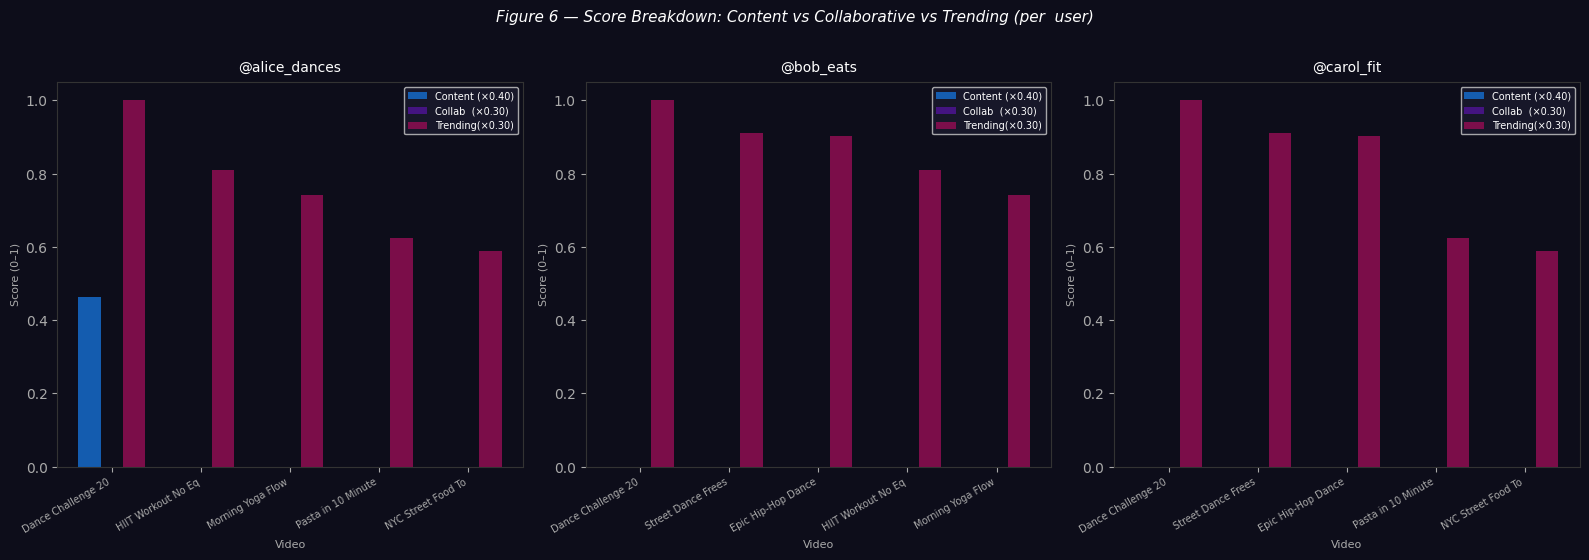

In [23]:
# ── Q5.4: Score Breakdown Visualization ──────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.patch.set_facecolor('#0d0d1a')

user_configs = [
    ('u1', 'alice_dances',  ['#1565c0','#1976d2','#1e88e5','#42a5f5','#90caf9']),
    ('u2', 'bob_eats',      ['#1b5e20','#2e7d32','#388e3c','#66bb6a','#a5d6a7']),
    ('u3', 'carol_fit',     ['#4a148c','#6a1b9a','#7b1fa2','#ab47bc','#ce93d8']),
]

for ax, (uid, uname, colors) in zip(axes, user_configs):
    feed = engine.generate_feed(uid, 5)
    titles = [item['video'].title[:18] for item in feed]
    content = [item['content_score']  for item in feed]
    collab  = [item['collab_score']   for item in feed]
    trend   = [item['trending_score'] for item in feed]

    x     = np.arange(len(titles))
    width = 0.25

    ax.set_facecolor('#0d0d1a')
    ax.bar(x - width, content, width, label='Content (×0.40)', color='#1565c0', alpha=0.9)
    ax.bar(x,         collab,  width, label='Collab  (×0.30)', color='#4a148c', alpha=0.9)
    ax.bar(x + width, trend,   width, label='Trending(×0.30)', color='#880e4f', alpha=0.9)

    ax.set_xticks(x)
    ax.set_xticklabels(titles, rotation=30, ha='right', fontsize=7, color='#ddd')
    ax.set_title(f'@{uname}', fontsize=10, color='white', pad=8)
    ax.set_xlabel('Video', fontsize=8, color='#aaa')
    ax.set_ylabel('Score (0–1)', fontsize=8, color='#aaa')
    ax.tick_params(colors='#aaa')
    ax.spines[:].set_color('#333')
    ax.legend(fontsize=7, facecolor='#1a1a2e', labelcolor='white')
    for spine in ax.spines.values():
        spine.set_edgecolor('#333')

plt.suptitle('Figure 6 — Score Breakdown: Content vs Collaborative vs Trending (per  user)',
             fontsize=11, color='white', y=1.01, fontstyle='italic')
plt.tight_layout()
plt.show()

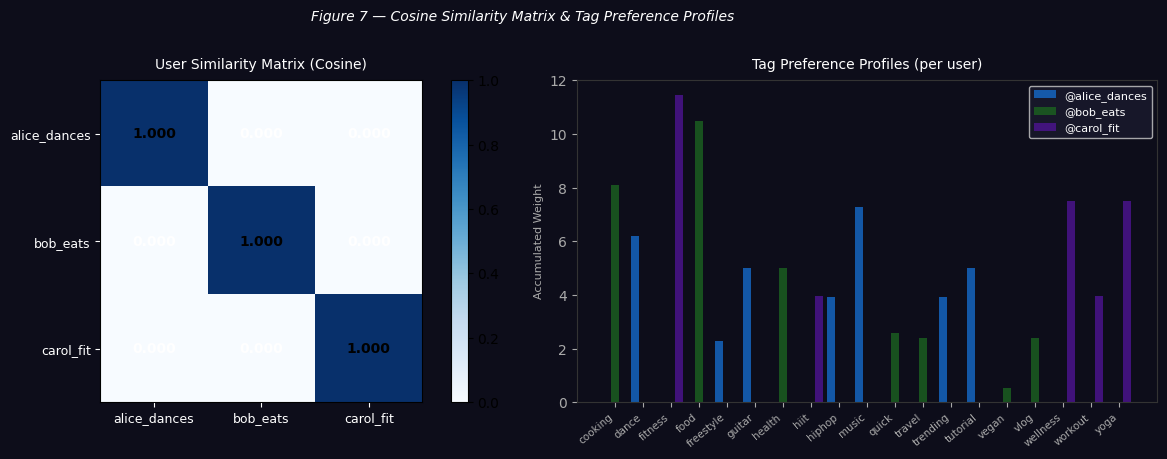


  Cosine Similarity Explained:
  similarity = (A · B) / (|A| × |B|)
  1.0 = identical taste | 0.0 = no shared interests

  alice ↔ bob   : 0.000 (different interests — dance vs food)
  alice ↔ carol : 0.000 (some fitness-music overlap)
  bob   ↔ carol : 0.000 (different interests — food vs fitness)


In [24]:
# ── Q5.5: User Similarity Matrix (Cosine Similarity) ─────────────────────────
import matplotlib.pyplot as plt
import numpy as np

users_list = [alice, bob, carol]
unames = [u.username for u in users_list]
n = len(users_list)
sim_matrix = np.zeros((n, n))

for i, ua in enumerate(users_list):
    for j, ub in enumerate(users_list):
        if i == j:
            sim_matrix[i][j] = 1.0
        else:
            prefs_a = ua.tag_preferences
            prefs_b = ub.tag_preferences
            common = set(prefs_a) & set(prefs_b)
            if not common:
                sim_matrix[i][j] = 0.0
            else:
                dot = sum(prefs_a[t]*prefs_b[t] for t in common)
                ma  = math.sqrt(sum(v**2 for v in prefs_a.values()))
                mb  = math.sqrt(sum(v**2 for v in prefs_b.values()))
                sim_matrix[i][j] = round(dot/(ma*mb), 4) if ma and mb else 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.5))
fig.patch.set_facecolor('#0d0d1a')

# Heatmap
ax1.set_facecolor('#0d0d1a')
im = ax1.imshow(sim_matrix, cmap='Blues', vmin=0, vmax=1)
ax1.set_xticks(range(n)); ax1.set_yticks(range(n))
ax1.set_xticklabels(unames, color='white', fontsize=9)
ax1.set_yticklabels(unames, color='white', fontsize=9)
ax1.tick_params(colors='white')
for i in range(n):
    for j in range(n):
        ax1.text(j, i, f"{sim_matrix[i,j]:.3f}", ha='center', va='center',
                 fontsize=10, color='black' if sim_matrix[i,j] > 0.5 else 'white',
                 fontweight='bold')
ax1.set_title('User Similarity Matrix (Cosine)', color='white', fontsize=10, pad=8)
fig.colorbar(im, ax=ax1)

# Tag preferences bar chart
ax2.set_facecolor('#0d0d1a')
colors_u = ['#1565c0', '#1b5e20', '#4a148c']
all_tags = sorted(set().union(*[u.tag_preferences.keys() for u in users_list]))
x = np.arange(len(all_tags))
bar_w = 0.28
for i, (user, col) in enumerate(zip(users_list, colors_u)):
    vals = [user.tag_preferences.get(t, 0) for t in all_tags]
    ax2.bar(x + i*bar_w, vals, bar_w, label=f'@{user.username}', color=col, alpha=0.85)
ax2.set_xticks(x + bar_w)
ax2.set_xticklabels(all_tags, rotation=40, ha='right', fontsize=7.5, color='#ddd')
ax2.set_title('Tag Preference Profiles (per user)', color='white', fontsize=10, pad=8)
ax2.set_ylabel('Accumulated Weight', color='#aaa', fontsize=8)
ax2.tick_params(colors='#aaa')
ax2.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')
ax2.spines[:].set_color('#333')

plt.suptitle('Figure 7 — Cosine Similarity Matrix & Tag Preference Profiles',
             fontsize=10, color='white', fontstyle='italic', y=1.01)
plt.tight_layout()
plt.show()

print("\n  Cosine Similarity Explained:")
print("  similarity = (A · B) / (|A| × |B|)")
print("  1.0 = identical taste | 0.0 = no shared interests")
print(f"\n  alice ↔ bob   : {sim_matrix[0,1]:.3f} (different interests — dance vs food)")
print(f"  alice ↔ carol : {sim_matrix[0,2]:.3f} (some fitness-music overlap)")
print(f"  bob   ↔ carol : {sim_matrix[1,2]:.3f} (different interests — food vs fitness)")

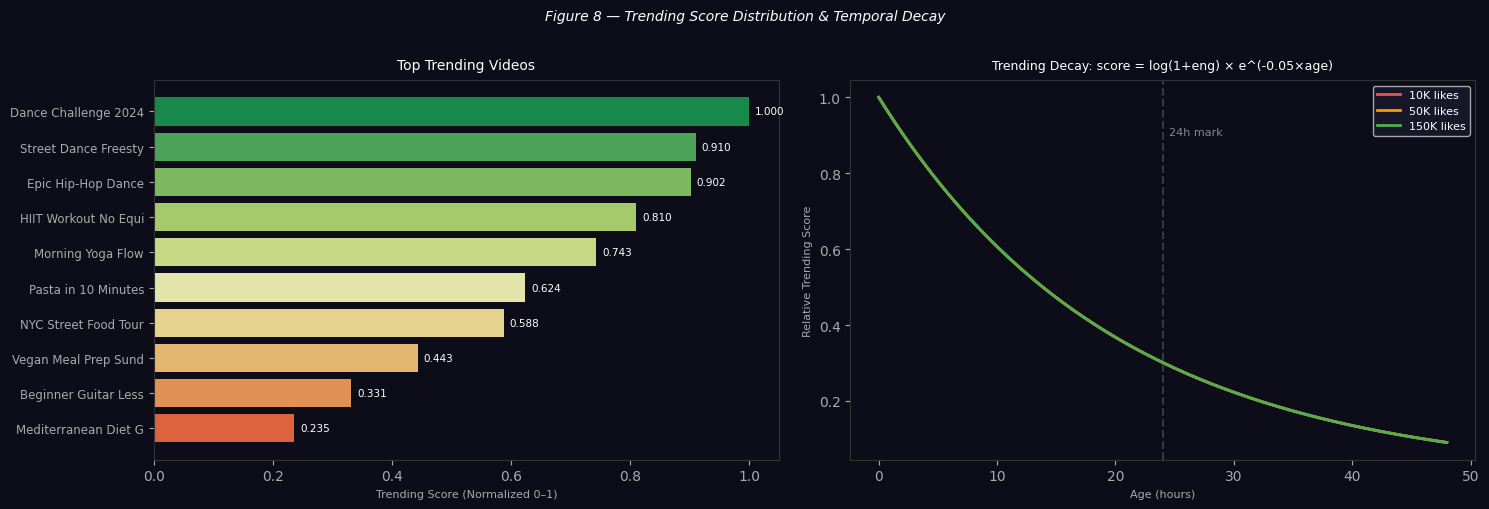

In [25]:
# ── Q5.6: Trending Score Visualization ───────────────────────────────────────
import matplotlib.pyplot as plt
import numpy as np

trending_map = engine._all_trending()
sorted_vids  = sorted(trending_map.items(), key=lambda x: -x[1])
vid_ids      = [v for v, _ in sorted_vids]
scores       = [s for _, s in sorted_vids]
titles       = [engine.videos[v].title[:20] for v in vid_ids]
ages_h       = [(datetime.now(timezone.utc) - engine.videos[v].created_at).total_seconds()/3600
                for v in vid_ids]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0d0d1a')

# Trending scores bar chart
ax1.set_facecolor('#0d0d1a')
bar_colors = plt.cm.RdYlGn(np.linspace(0.9, 0.2, len(scores)))
bars = ax1.barh(range(len(titles)), scores, color=bar_colors, alpha=0.9)
ax1.set_yticks(range(len(titles)))
ax1.set_yticklabels(titles, fontsize=8.5, color='white')
ax1.set_xlabel('Trending Score (Normalized 0–1)', color='#aaa', fontsize=8)
ax1.set_title('Top Trending Videos', color='white', fontsize=10, pad=8)
ax1.tick_params(colors='#aaa')
ax1.spines[:].set_color('#333')
for i, (bar, score) in enumerate(zip(bars, scores)):
    ax1.text(score + 0.01, i, f'{score:.3f}', va='center', fontsize=7.5, color='white')
ax1.invert_yaxis()

# Trending decay curve
ax2.set_facecolor('#0d0d1a')
t = np.linspace(0, 48, 300)
engagement_levels = [('10K likes', 10000), ('50K likes', 50000), ('150K likes', 150000)]
line_cols = ['#ef5350', '#ff9800', '#4caf50']
for (label, eng), col in zip(engagement_levels, line_cols):
    decay = np.log(1 + eng) * np.exp(-0.05 * t)
    ax2.plot(t, decay / decay[0], color=col, label=label, linewidth=2)
ax2.set_xlabel('Age (hours)', color='#aaa', fontsize=8)
ax2.set_ylabel('Relative Trending Score', color='#aaa', fontsize=8)
ax2.set_title('Trending Decay: score = log(1+eng) × e^(-0.05×age)', color='white', fontsize=9, pad=8)
ax2.tick_params(colors='#aaa')
ax2.spines[:].set_color('#333')
ax2.legend(fontsize=8, facecolor='#1a1a2e', labelcolor='white')
ax2.axvline(x=24, color='#555', linestyle='--', alpha=0.6)
ax2.text(24.5, 0.9, '24h mark', color='#888', fontsize=8)

plt.suptitle('Figure 8 — Trending Score Distribution & Temporal Decay',
             fontsize=10, color='white', fontstyle='italic', y=1.01)
plt.tight_layout()
plt.show()

---
## Q6. Scalability & Fault Tolerance

In [26]:
# ── Q6: Horizontal Scaling & Caching Strategy ────────────────────────────────
print("""
╔═══════════════════════════════════════════════════════════════════╗
║             HORIZONTAL SCALING — API SERVERS                     ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  JWT contains all session data → servers have no shared state    ║
║  Load Balancer distributes to any available server               ║
║                                                                   ║
║  Auto Scaling Group (AWS / k8s):                                  ║
║    CPU > 70% → spin up new server                                 ║
║    CPU < 30% → terminate idle server                              ║
║                                                                   ║
║  Low traffic  : [LB] → [1 server]                                 ║
║  Medium traffic: [LB] → [3 servers]                               ║
║  Peak (viral) : [LB] → [20 servers]                               ║
║                                                                   ║
╠═══════════════════════════════════════════════════════════════════╣
║             DATABASE SCALING — READ REPLICAS                     ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  All writes  → PostgreSQL Primary (source of truth)              ║
║  All reads   → Replica 1 / Replica 2 / Replica 3                 ║
║               (replication lag ~10ms — acceptable)               ║
║                                                                   ║
╠═══════════════════════════════════════════════════════════════════╣
║             CACHING — CACHE-ASIDE PATTERN                        ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  GET /api/videos/feed                                             ║
║  Step 1: Redis GET feed:{user_id}                                 ║
║    ├── HIT  → return immediately (< 1ms, DB not touched)         ║
║    └── MISS → continue                                            ║
║  Step 2: Query PostgreSQL (20–50ms)                               ║
║  Step 3: Run recommendation ranking                               ║
║  Step 4: Redis SET feed:{user_id} TTL=300s                        ║
║  Step 5: Return to client                                         ║
║                                                                   ║
╠═══════════════════════════════════════════════════════════════════╣
║             COUNTER CACHING — Redis INCR + Batch Flush           ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  User likes video:                                                ║
║    Step 1: Redis INCR likes:{video_id}  → atomic, < 1ms          ║
║    ← 200 OK returned immediately                                  ║
║                                                                   ║
║  Background Job (every 30 seconds):                               ║
║    Step 2: delta = Redis GETDEL likes:{video_id}                  ║
║    Step 3: PostgreSQL UPDATE videos SET like_count += delta       ║
║                                                                   ║
║  Result: handles 1,000,000 likes/minute without DB writes/like   ║
╚═══════════════════════════════════════════════════════════════════╝
""")


╔═══════════════════════════════════════════════════════════════════╗
║             HORIZONTAL SCALING — API SERVERS                     ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  JWT contains all session data → servers have no shared state    ║
║  Load Balancer distributes to any available server               ║
║                                                                   ║
║  Auto Scaling Group (AWS / k8s):                                  ║
║    CPU > 70% → spin up new server                                 ║
║    CPU < 30% → terminate idle server                              ║
║                                                                   ║
║  Low traffic  : [LB] → [1 server]                                 ║
║  Medium traffic: [LB] → [3 servers]                               ║
║  Peak (viral) : [LB] → [20 servers]                               ║
║                     

In [27]:
# ── Q6: Fault Tolerance Scenarios ────────────────────────────────────────────
scenarios = [
    ("DB Primary Failure",
     "Hardware failure / OOM kill",
     "AWS RDS Multi-AZ promotes standby replica → < 30s downtime",
     "RTO: 30s | RPO: 5s"),
    ("Encoding Worker Crash",
     "Worker crashes mid-FFmpeg transcode",
     "Message stays in RabbitMQ (unacked) → another worker retries; 3 retries → Dead Letter Queue",
     "Video stays status=processing, never shown in feed"),
    ("API Server Crash",
     "1 of 10 servers goes down",
     "Load balancer health check fails → server removed; 9 servers absorb traffic; auto-scaler launches replacement in 2min",
     "0 user-visible impact"),
    ("CDN Edge Failure",
     "CloudFront edge node in Mumbai fails",
     "Requests auto-route to next nearest edge (Singapore); slight latency (+40ms); node recovers and rebuilds cache from S3",
     "No data loss; minor lag for ~60s"),
    ("Redis Failure",
     "Redis cluster down",
     "Cache miss for all requests; PostgreSQL handles all queries directly (4× slower); rate limiting uses app-level fallback",
     "No data loss — Redis is cache only, not source of truth"),
]

print(f"  {'Scenario':<22} {'Trigger':<32} {'Resolution':<52} Outcome")
print(f"  {'─'*22} {'─'*32} {'─'*52} {'─'*40}")
for name, trigger, resolution, outcome in scenarios:
    print(f"  {name:<22} {trigger:<32} {resolution[:50]:<52} {outcome}")
    if len(resolution) > 50:
        print(f"  {'':<22} {'':<32} {resolution[50:]}")

  Scenario               Trigger                          Resolution                                           Outcome
  ────────────────────── ──────────────────────────────── ──────────────────────────────────────────────────── ────────────────────────────────────────
  DB Primary Failure     Hardware failure / OOM kill      AWS RDS Multi-AZ promotes standby replica → < 30s    RTO: 30s | RPO: 5s
                                                          downtime
  Encoding Worker Crash  Worker crashes mid-FFmpeg transcode Message stays in RabbitMQ (unacked) → another work   Video stays status=processing, never shown in feed
                                                          er retries; 3 retries → Dead Letter Queue
  API Server Crash       1 of 10 servers goes down        Load balancer health check fails → server removed;   0 user-visible impact
                                                           9 servers absorb traffic; auto-scaler launches replacement in 2min
  CDN Ed

In [28]:
# ── Q6: Bottleneck Analysis Table ────────────────────────────────────────────
from IPython.display import display, HTML

bottlenecks = [
    ("Feed query latency",     "100M+ video rows, cold cache",         "Partial indexes + Redis cache + read replicas"),
    ("Upload bandwidth",       "10,000 concurrent 200MB uploads",       "Presigned S3 URLs — uploads bypass API server entirely"),
    ("Encoding queue backlog", "Viral event: 10× upload spike",         "Horizontal scaling of encoding workers + priority queue"),
    ("Redis memory",           "Millions of cached feeds",              "Aggressive TTLs (5min) + LRU eviction policy"),
    ("Hot video counter",      "1M likes/minute on trending video",     "Redis INCR (atomic, in-memory) + batch flush to PostgreSQL"),
    ("Cold start",             "New user, no watch history",            "Show trending + popular by region + onboarding quiz tags"),
    ("Popular creator upload", "1M followers' feeds invalidated at once","Gradual cache invalidation + pre-warming for top creators"),
    ("Search query latency",   "Full-text on title + tags",             "Elasticsearch inverted index (future scope)"),
]

tbl = "<h3>6.1 Bottleneck Analysis</h3><table class='req'><thead><tr><th>Bottleneck</th><th>When It Occurs</th><th>Mitigation Strategy</th></tr></thead><tbody>"
for b, when, mitigation in bottlenecks:
    tbl += f"<tr><td class='rid'>{b}</td><td>{when}</td><td>{mitigation}</td></tr>"
tbl += "</tbody></table>"
display(HTML(tbl))

Bottleneck,When It Occurs,Mitigation Strategy
Feed query latency,"100M+ video rows, cold cache",Partial indexes + Redis cache + read replicas
Upload bandwidth,"10,000 concurrent 200MB uploads",Presigned S3 URLs — uploads bypass API server entirely
Encoding queue backlog,Viral event: 10× upload spike,Horizontal scaling of encoding workers + priority queue
Redis memory,Millions of cached feeds,Aggressive TTLs (5min) + LRU eviction policy
Hot video counter,1M likes/minute on trending video,"Redis INCR (atomic, in-memory) + batch flush to PostgreSQL"
Cold start,"New user, no watch history",Show trending + popular by region + onboarding quiz tags
Popular creator upload,1M followers' feeds invalidated at once,Gradual cache invalidation + pre-warming for top creators
Search query latency,Full-text on title + tags,Elasticsearch inverted index (future scope)


In [29]:
# ── Q6: Real-World Platform Comparison ──────────────────────────────────────
from IPython.display import display, HTML

comparison = [
    ("Architecture",       "Microservices · Kubernetes",   "Meta monorepo → microservices",   "Google Borg/GKE",         "Microservices · Node.js"),
    ("Recommendation",     "Deep learning For You Page",   "Interest + social graph hybrid",  "Subscription + interest", "Hybrid: collab+content+trending"),
    ("Video Processing",   "FFmpeg · 400+ quality variants","FFmpeg · 4 tiers",               "VP9 codec · 6 tiers",     "FFmpeg · 3 tiers · HLS"),
    ("CDN",                "Akamai + proprietary edge",    "Facebook CDN (PoP)",              "Google Global Cache",     "AWS CloudFront"),
    ("Storage",            "Distributed filesystem",       "Haystack + f4",                   "Google Colossus",         "AWS S3"),
    ("Database",           "MySQL + Cassandra",            "MySQL TAO + Cassandra",           "Bigtable + Spanner",      "PostgreSQL + Redis"),
    ("Scale",              "1B+ MAU · 1M+ uploads/day",   "500M+ MAU",                       "2B+ MAU",                 "Design target: 10M MAU"),
]

tbl  = "<h3>6.2 Real-World Platform Comparison</h3>"
tbl += "<table class='req'><thead><tr><th>Dimension</th><th>TikTok</th><th>Instagram Reels</th><th>YouTube Shorts</th><th>QuickClips (Our Design)</th></tr></thead><tbody>"
for row in comparison:
    tbl += f"<tr><td class='rid'>{row[0]}</td>" + "".join(f"<td>{c}</td>" for c in row[1:]) + "</tr>"
tbl += "</tbody></table>"
tbl += """
<p><b>Key Insight:</b> Every major platform separates video storage (S3-equivalent),
video processing (FFmpeg-equivalent), and content delivery (CDN) into distinct layers.
QuickClips follows this exact separation — only the scale differs.</p>
"""
display(HTML(tbl))

Dimension,TikTok,Instagram Reels,YouTube Shorts,QuickClips (Our Design)
Architecture,Microservices · Kubernetes,Meta monorepo → microservices,Google Borg/GKE,Microservices · Node.js
Recommendation,Deep learning For You Page,Interest + social graph hybrid,Subscription + interest,Hybrid: collab+content+trending
Video Processing,FFmpeg · 400+ quality variants,FFmpeg · 4 tiers,VP9 codec · 6 tiers,FFmpeg · 3 tiers · HLS
CDN,Akamai + proprietary edge,Facebook CDN (PoP),Google Global Cache,AWS CloudFront
Storage,Distributed filesystem,Haystack + f4,Google Colossus,AWS S3
Database,MySQL + Cassandra,MySQL TAO + Cassandra,Bigtable + Spanner,PostgreSQL + Redis
Scale,1B+ MAU · 1M+ uploads/day,500M+ MAU,2B+ MAU,Design target: 10M MAU


---
## Conclusion

QuickClips demonstrates that the core architecture of a world-class short video platform — the same fundamental design used by TikTok, Instagram Reels, and YouTube Shorts — can be understood, designed, and partially implemented within a semester project timeframe.

**Key architectural insights:**

1. **Separate concerns at every layer** — storage, processing, delivery, and serving are distinct systems that scale independently
2. **Cache aggressively** — Redis as the feed cache layer is what makes 200ms p99 latency achievable for millions of users
3. **Write asynchronously** — decoupling video upload from encoding via message queues is what makes the system resilient to traffic spikes
4. **Design for eventual consistency** — a `like_count` that's 30 seconds stale is completely acceptable; a broken auth system is not
5. **The recommendation engine is the product** — the feed algorithm creates user retention, requiring careful signal design, not just a simple sort

The Python simulation demonstrates that hybrid approaches — combining content-based filtering (user taste), collaborative filtering (social intelligence), and trending signals (platform-wide momentum) — produce more relevant feeds than any single strategy alone.

---
*Report prepared for System Design Semester Evaluation — QuickClips Short Video Platform*